## Imports

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [30]:
df = pd.read_csv('datasetml_2026.csv')
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [31]:
df.shape

(10000, 12)

In [32]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

In [33]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [34]:
# cari yg null
df.isnull().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

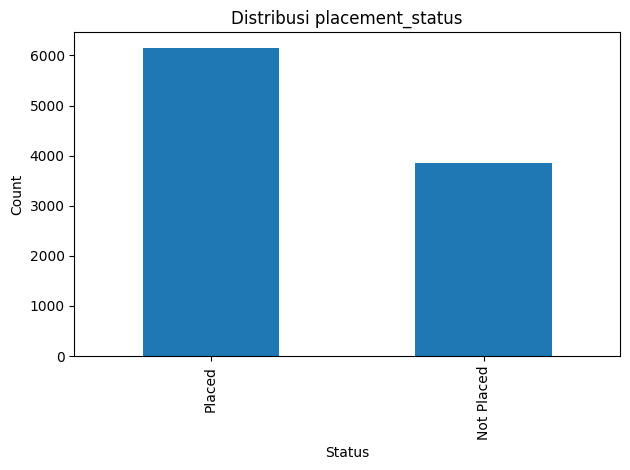

In [35]:
# Distribusi target
df['placement_status'].value_counts().plot(kind='bar')
plt.title('Distribusi placement_status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

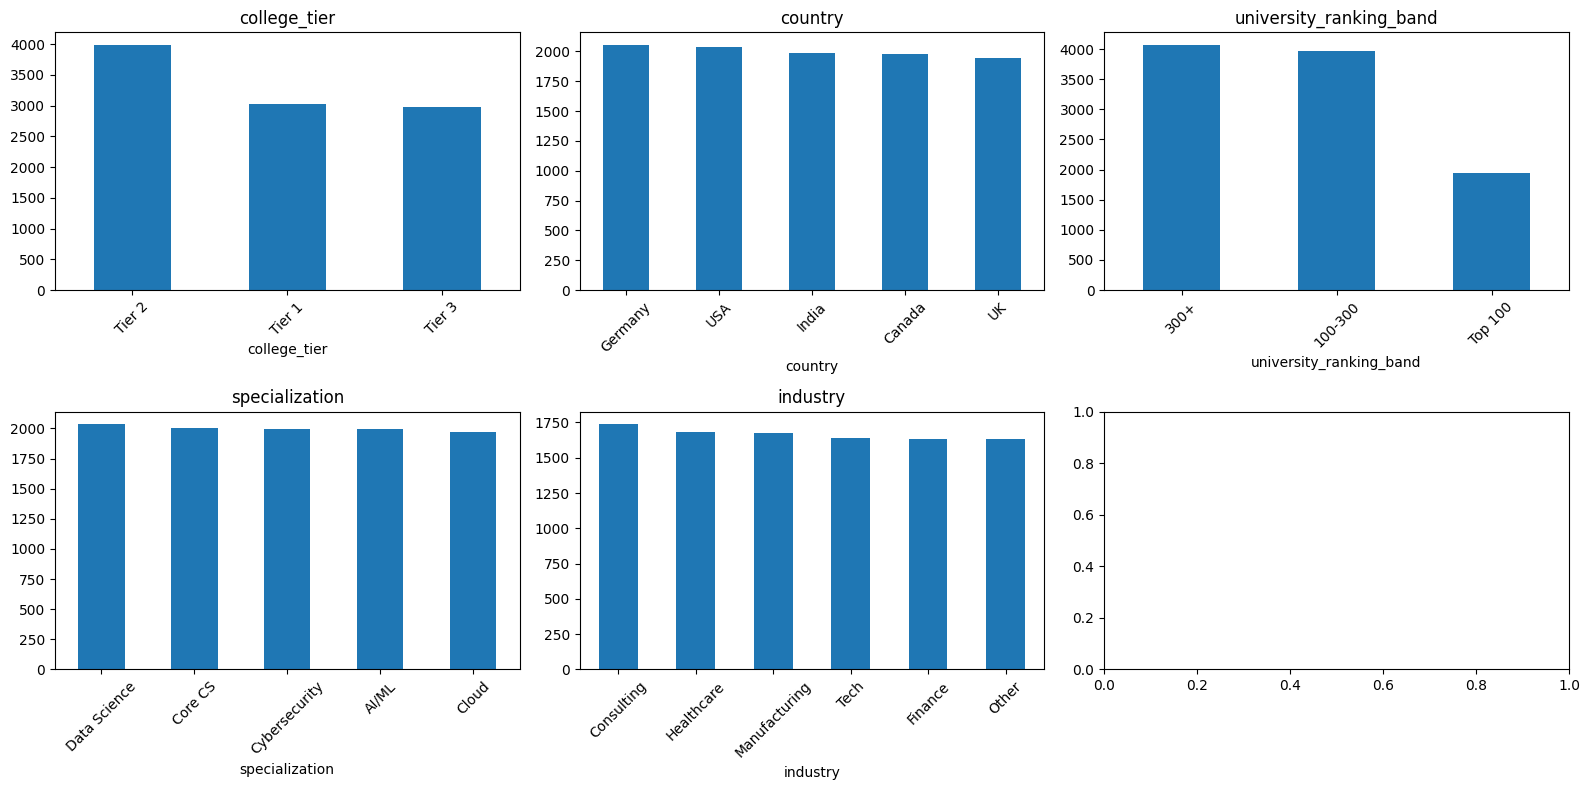

In [36]:
# Distribusi fitur kategorikal
cat_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

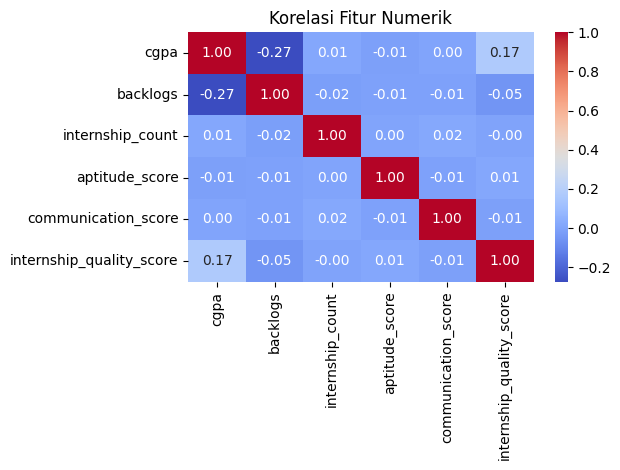

In [37]:
# Korelasi fitur numerik
num_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score',
            'communication_score', 'internship_quality_score']

import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

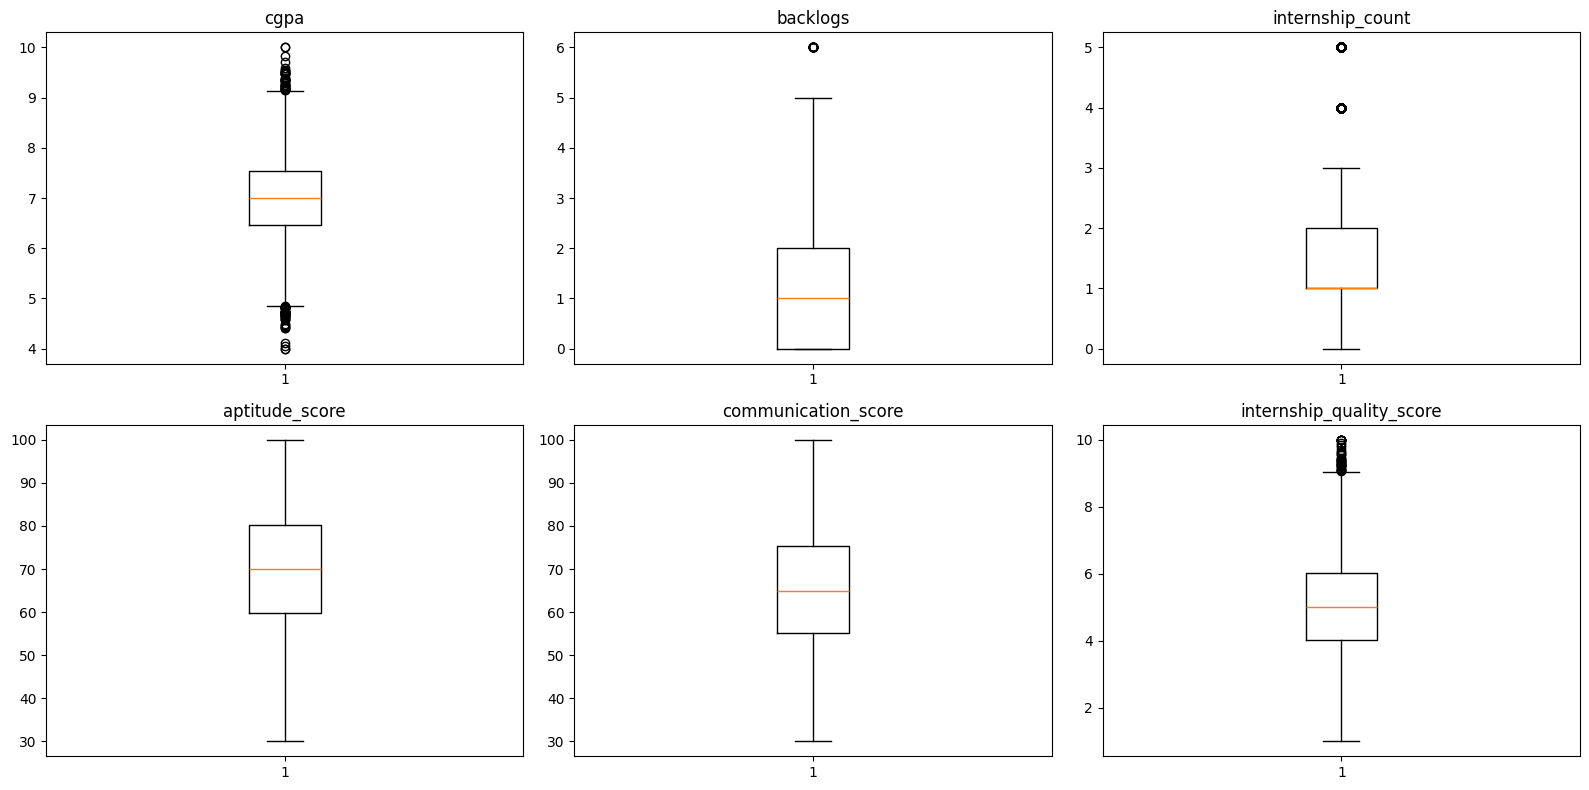

In [38]:
# Outlier
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Preprocessing

In [39]:
# encode kolom kategorikal dengan label encoding
cat_cols = ['college_tier', 'university_ranking_band', 'country', 'specialization', 'industry']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [40]:
# pisah fitur dan target
X = df.drop(columns=['placement_status']).values
y = le.fit_transform(df['placement_status'].astype(str)).reshape(-1, 1)

In [41]:
# normalisasi fitur numerik
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [42]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (7200, 11), Val: (800, 11), Test: (2000, 11)


## Model Testing

Random init, 100 epoch dengan 0.1% learning rate

Training Custom FFNN Model...
Epoch   1/100 [>....................] - loss: 0.6898 - acc: 0.6147 - val_loss: 0.6874 - val_acc: 0.6125
Epoch   2/100 [>....................] - loss: 0.6852 - acc: 0.6147 - val_loss: 0.6834 - val_acc: 0.6125
Epoch   3/100 [>....................] - loss: 0.6815 - acc: 0.6147 - val_loss: 0.6802 - val_acc: 0.6125
Epoch   4/100 [>....................] - loss: 0.6786 - acc: 0.6147 - val_loss: 0.6776 - val_acc: 0.6125
Epoch   5/100 [=>...................] - loss: 0.6762 - acc: 0.6147 - val_loss: 0.6756 - val_acc: 0.6125
Epoch   6/100 [=>...................] - loss: 0.6743 - acc: 0.6147 - val_loss: 0.6740 - val_acc: 0.6125
Epoch   7/100 [=>...................] - loss: 0.6728 - acc: 0.6147 - val_loss: 0.6727 - val_acc: 0.6125
Epoch   8/100 [=>...................] - loss: 0.6716 - acc: 0.6147 - val_loss: 0.6717 - val_acc: 0.6125
Epoch   9/100 [=>...................] - loss: 0.6706 - acc: 0.6147 - val_loss: 0.6708 - val_acc: 0.6125
Epoch  10/100 [==>................

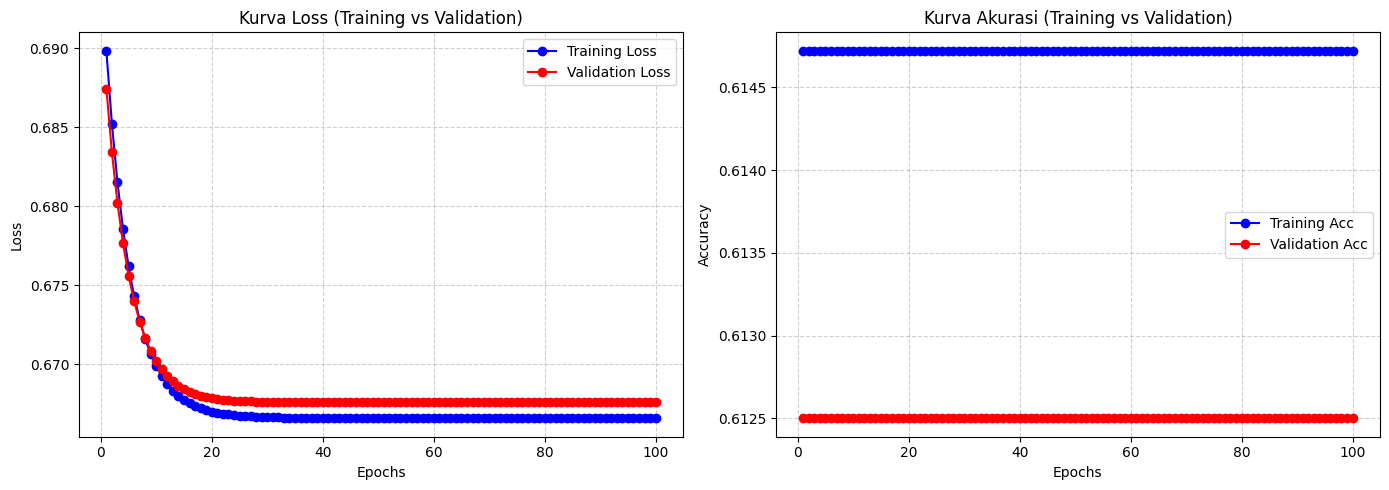


CUSTOM FFNN MODEL - CLASSIFICATION REPORT
--- Laporan Klasifikasi ---
Total Data : 2000
Akurasi    : 61.25%

CONFUSION MATRIX - CUSTOM FFNN
[[   0  775]
 [   0 1225]]


In [43]:
from ffnn.ffnn import FFNN
from ffnn import utils
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report as sklearn_classification_report

# Convert labels to one-hot encoding for FFNN
y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_test_onehot = utils.create_one_hot(y_test.ravel(), num_classes=2)

input_dim = X_train.shape[1]
num_classes = 2

# Create and train model with improved hyperparameters
model = FFNN(
    layer_sizes=[input_dim, 64, 32, num_classes], 
    activations=["relu", "relu", "softmax"],
    init_method="random_normal",
    learning_rate=0.001, 
    epochs=100, 
    batch_size=16, 
    l2_lambda=0.0001,
    verbose=1,
    variance=0.01,
    seed=42
)

print("Training Custom FFNN Model...")
# Train model
history = model.fit(
    X_train, y_train_onehot,
    X_val=X_test, y_val=y_test_onehot
)

# Plot training history
utils.plot_history(history)

# Prediksi data test
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Tampilkan Akurasi Akhir
print("\n" + "="*60)
print("CUSTOM FFNN MODEL - CLASSIFICATION REPORT")
print("="*60)
utils.classification_report(y_test.ravel(), y_pred_labels)

print("\n" + "="*60)
print("CONFUSION MATRIX - CUSTOM FFNN")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_labels))

Random init layers & activation, 100 iteration with 10% learning rate.

ATTEMPT 2: Higher Learning Rate with Better Initialization

Training Model 2 with LR=0.1...
Epoch   1/100 [>....................] - loss: 0.6693 - acc: 0.6125 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   2/100 [>....................] - loss: 0.6668 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   3/100 [>....................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   4/100 [>....................] - loss: 0.6668 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   5/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6677 - val_acc: 0.6125
Epoch   6/100 [=>...................] - loss: 0.6668 - acc: 0.6147 - val_loss: 0.6675 - val_acc: 0.6125
Epoch   7/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6675 - val_acc: 0.6125
Epoch   8/100 [=>...................] - loss: 0.6666 - acc: 0.6147 - val_loss: 0.6678 - val_acc: 0.6125
Epoch   9/100 [=>...................] - loss: 0.6664 - acc: 0.6147 - val_los

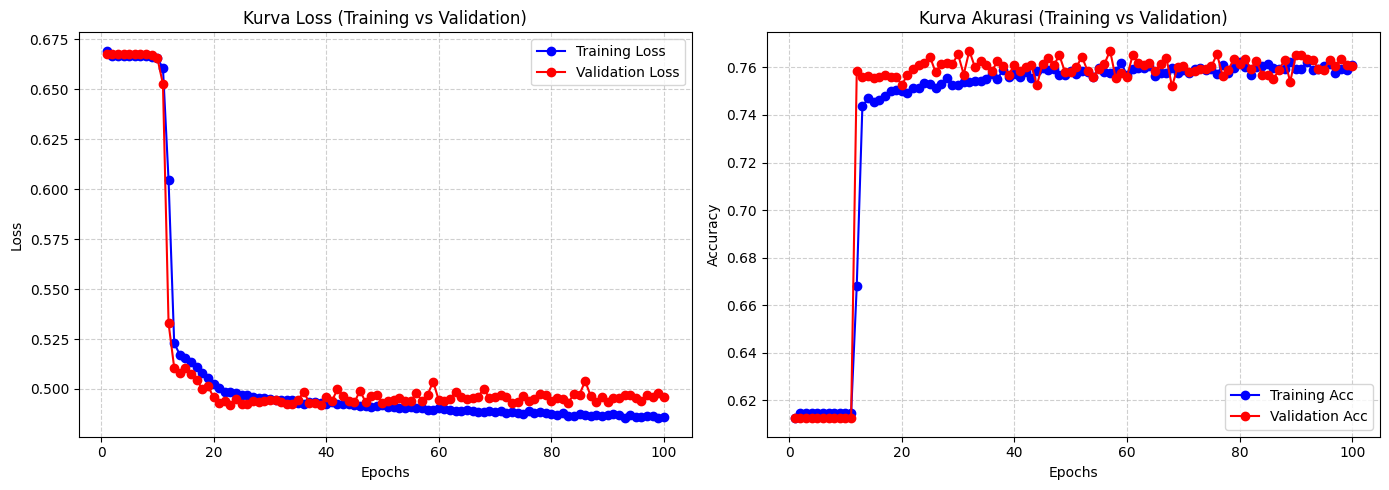


MODEL 2 - CLASSIFICATION REPORT
--- Laporan Klasifikasi ---
Total Data : 2000
Akurasi    : 76.05%

CONFUSION MATRIX - MODEL 2
[[ 472  303]
 [ 176 1049]]

MODEL 2 - DIAGNOSTIC
Initial train loss: 0.669341
Final train loss: 0.486116
Initial train accuracy: 0.612500
Final train accuracy: 0.760833
Test accuracy: 0.760500


In [44]:
print("="*60)
print("ATTEMPT 2: Higher Learning Rate with Better Initialization")
print("="*60)

# Re-import fresh
from ffnn.ffnn import FFNN
from ffnn import utils
from ffnn import losses

model2 = FFNN(
    layer_sizes=[input_dim, 32, 16, num_classes],
    activations=["relu", "relu", "softmax"],
    init_method="random_normal",
    learning_rate=0.1,  # Much higher learning rate
    epochs=100,
    batch_size=32,
    l2_lambda=0.0, 
    verbose=1,
    variance=0.1, 
    seed=42
)

print("\nTraining Model 2 with LR=0.1...")
history2 = model2.fit(
    X_train, y_train_onehot,
    X_val=X_test, y_val=y_test_onehot
)

utils.plot_history(history2)

# Predictions
y_pred_probs2 = model2.predict(X_test)
y_pred_labels2 = np.argmax(y_pred_probs2, axis=1)

print("\n" + "="*60)
print("MODEL 2 - CLASSIFICATION REPORT")
print("="*60)
utils.classification_report(y_test.ravel(), y_pred_labels2)

print("\n" + "="*60)
print("CONFUSION MATRIX - MODEL 2")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_labels2))

# Diagnostic
print("\n" + "="*60)
print("MODEL 2 - DIAGNOSTIC")
print("="*60)
print(f"Initial train loss: {history2['train_loss'][0]:.6f}")
print(f"Final train loss: {history2['train_loss'][-1]:.6f}")
print(f"Initial train accuracy: {history2['train_acc'][0]:.6f}")
print(f"Final train accuracy: {history2['train_acc'][-1]:.6f}")
print(f"Test accuracy: {np.mean(y_pred_labels2 == y_test.ravel()):.6f}")

### 1. Hyperparameter

#### Pengaruh Depth

Eksperimen dengan 3 variasi depth (banyak layer) menggunakan arsitektur dan hyperparameter yang sama.

In [52]:
# Fixed hyperparams
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42
LEARNING_RATE = 0.01

y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_val_onehot   = utils.create_one_hot(y_val.ravel(), num_classes=2)
y_test_onehot  = utils.create_one_hot(y_test.ravel(), num_classes=2)

depths = [2, 3, 4]  # Number of hidden layers
histories = {}
results = {}

for depth in depths:
    layer_sizes = [X_train.shape[1]] + [64] * depth + [2]
    activations = ["relu"] * depth + ["softmax"]
    print(f"\n{'='*50}\nTraining with Depth = {depth}\n{'='*50}")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=activations,
        init_method="he",
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=1
    )
    history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
    histories[depth] = history
    results[depth] = {
        "model": model,
        "accuracy": accuracy_score(y_test.ravel(), np.argmax(model.predict(X_test), axis=1))
    }


Training with Depth = 2
Epoch   1/100 [>....................] - loss: 0.7630 - acc: 0.5889 - val_loss: 0.5807 - val_acc: 0.6925
Epoch   2/100 [>....................] - loss: 0.5777 - acc: 0.7024 - val_loss: 0.5242 - val_acc: 0.7163
Epoch   3/100 [>....................] - loss: 0.5467 - acc: 0.7236 - val_loss: 0.5101 - val_acc: 0.7325
Epoch   4/100 [>....................] - loss: 0.5357 - acc: 0.7304 - val_loss: 0.5044 - val_acc: 0.7312
Epoch   5/100 [=>...................] - loss: 0.5294 - acc: 0.7353 - val_loss: 0.5003 - val_acc: 0.7438
Epoch   6/100 [=>...................] - loss: 0.5251 - acc: 0.7374 - val_loss: 0.4974 - val_acc: 0.7462
Epoch   7/100 [=>...................] - loss: 0.5217 - acc: 0.7411 - val_loss: 0.4946 - val_acc: 0.7450
Epoch   8/100 [=>...................] - loss: 0.5187 - acc: 0.7431 - val_loss: 0.4935 - val_acc: 0.7438
Epoch   9/100 [=>...................] - loss: 0.5162 - acc: 0.7433 - val_loss: 0.4921 - val_acc: 0.7425
Epoch  10/100 [==>..................] -

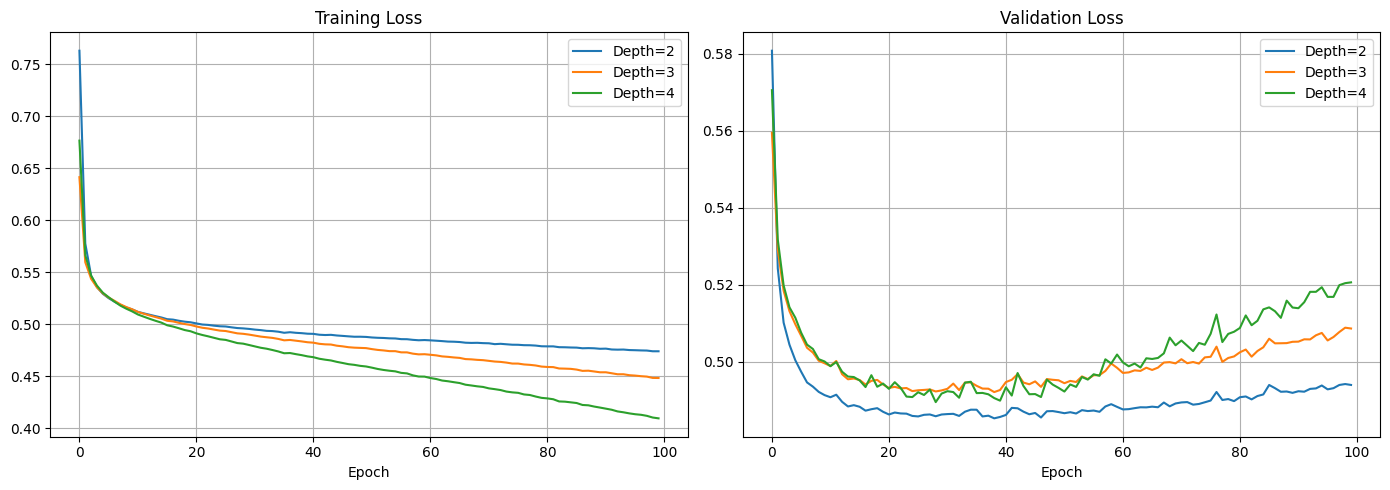

In [53]:
# Perbandingan training & validation loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for depth in depths:
    axes[0].plot(histories[depth]['train_loss'], label=f'Depth={depth}')
    axes[1].plot(histories[depth]['val_loss'],   label=f'Depth={depth}')

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

Depth=4 konvergen paling cepat dan mencapai training loss terendah (~0.41), namun validation loss-nya mulai naik secara bertahap setelah epoch ~30 hingga mencapai titik tertingginya di akhir epoch (~0.52) yang mengindikasikan terjadinya overfitting. Depth=2 menunjukkan konvergensi yang paling stabil; meskipun training loss-nya paling tinggi, model ini berhasil mencapai dan mempertahankan validation loss terendah (~0.49) dengan gap training dan validation loss yang kecil. Depth=3 berada di antara keduanya, dengan training loss yang lebih rendah dari Depth=2 (~0.45) namun validation loss-nya mulai menunjukkan tren kenaikan setelah epoch ~50, mengindikasikan awal mula terjadinya overfitting yang ringan.

In [54]:
# Perbandingan akurasi akhir

for depth in depths:
    print(f"Depth={depth} | Test Accuracy: {results[depth]['accuracy']:.4f}")

Depth=2 | Test Accuracy: 0.7470
Depth=3 | Test Accuracy: 0.7420
Depth=4 | Test Accuracy: 0.7330


Depth=2 menghasilkan akurasi tes tertinggi (74.70%). Depth=4 memiliki kompleksitas yang terlalu besar sehingga cenderung mengalami overfitting (terlalu menghafal data latih), menghasilkan akurasi tes terendah (73.30%). Depth=3 performanya cukup baik (74.20%) namun masih di bawah Depth=2, mengindikasikan bahwa penambahan kedalaman lapisan pada titik ini justru mulai mengurangi kemampuan model untuk menggeneralisasi data tes yang belum pernah dilihat sebelumnya.

#### Pengaruh Width

Eksperimen dengan 3 variasi width (jumlah neuron per layer) menggunakan arsitektur dan hyperparameter yang sama.

In [55]:
# Fixed hyperparams
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42
LEARNING_RATE = 0.01

widths = [32, 64, 128]  # Number of neurons per layer
histories_width = {}
results_width = {}

for width in widths:
    layer_sizes = [X_train.shape[1]] + [width] * 3 + [2]
    activations = ["relu"] * 3 + ["softmax"]
    print(f"\n{'='*50}\nTraining with Width = {width}\n{'='*50}")
    model = FFNN(
        layer_sizes=layer_sizes,
        activations=activations,
        init_method="he",
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=1
    )
    history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
    histories_width[width] = history
    results_width[width] = {
        "model": model,
        "accuracy": accuracy_score(y_test.ravel(), np.argmax(model.predict(X_test), axis=1))
    }


Training with Width = 32
Epoch   1/100 [>....................] - loss: 0.7032 - acc: 0.6022 - val_loss: 0.5792 - val_acc: 0.6913
Epoch   2/100 [>....................] - loss: 0.5785 - acc: 0.6982 - val_loss: 0.5354 - val_acc: 0.7388
Epoch   3/100 [>....................] - loss: 0.5607 - acc: 0.7140 - val_loss: 0.5216 - val_acc: 0.7488
Epoch   4/100 [>....................] - loss: 0.5524 - acc: 0.7200 - val_loss: 0.5150 - val_acc: 0.7550
Epoch   5/100 [=>...................] - loss: 0.5469 - acc: 0.7253 - val_loss: 0.5093 - val_acc: 0.7588
Epoch   6/100 [=>...................] - loss: 0.5431 - acc: 0.7256 - val_loss: 0.5065 - val_acc: 0.7575
Epoch   7/100 [=>...................] - loss: 0.5398 - acc: 0.7286 - val_loss: 0.5036 - val_acc: 0.7625
Epoch   8/100 [=>...................] - loss: 0.5371 - acc: 0.7293 - val_loss: 0.5038 - val_acc: 0.7650
Epoch   9/100 [=>...................] - loss: 0.5350 - acc: 0.7343 - val_loss: 0.5011 - val_acc: 0.7588
Epoch  10/100 [==>..................] 

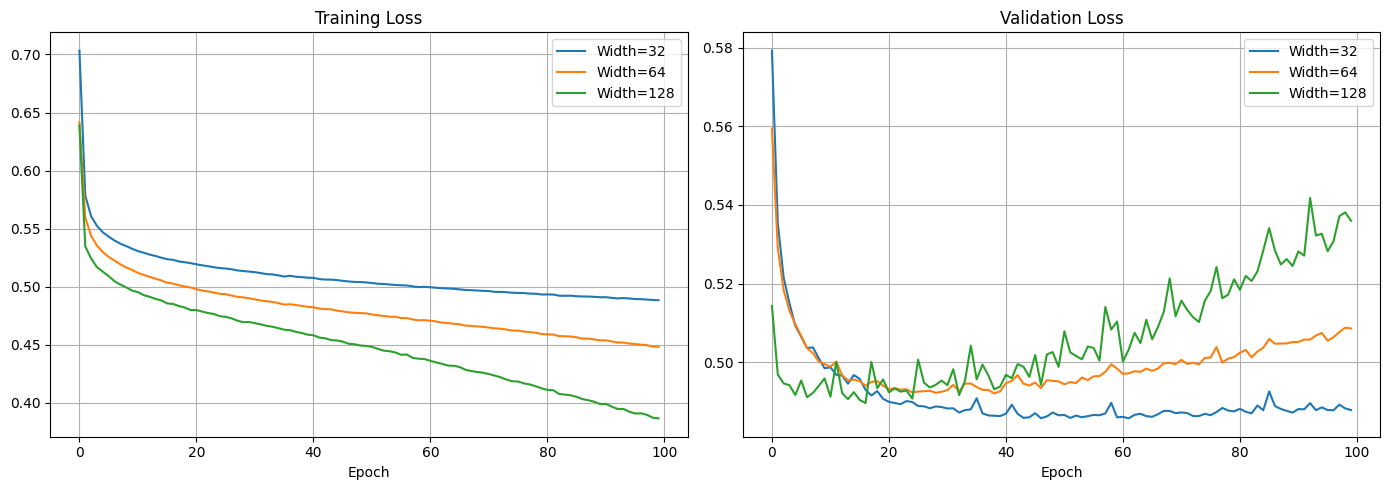

In [56]:
# Perbandingan training & validation loss untuk Width

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for width in widths:
    axes[0].plot(histories_width[width]['train_loss'], label=f'Width={width}')
    axes[1].plot(histories_width[width]['val_loss'],   label=f'Width={width}')

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

Width=128 konvergen paling cepat dan mencapai training loss terendah, namun validation loss-nya naik secara signifikan dan sangat fluktuatif setelah epoch ~20 hingga mencapai ~0.54, mengindikasikan terjadinya overfitting yang jelas. Width=32 menunjukkan konvergensi yang stabil dengan gap training dan validation loss yang kecil dan paling konsisten (bertahan di kisaran ~0.49) tanpa menunjukkan tanda-tanda kenaikan hingga akhir epoch. Width=64 menunjukkan performa di antara keduanya; training loss-nya terus menurun dengan baik, namun validation loss-nya mulai menunjukkan tren kenaikan perlahan setelah epoch ~40, mengindikasikan awal mula terjadinya overfitting ringan.

In [57]:
for width in widths:
    print(f"Width={width} | Test Accuracy: {results_width[width]['accuracy']:.4f}")

Width=32 | Test Accuracy: 0.7435
Width=64 | Test Accuracy: 0.7420
Width=128 | Test Accuracy: 0.7335


Width=32 menghasilkan akurasi tertinggi (74.35%). Width=128 terlalu kompleks dan memiliki kapasitas parameter yang terlalu besar, sehingga kemungkinan besar mengalami overfitting pada data latih yang menghasilkan akurasi tes terendah (73.35%). Width=64 performanya cukup baik (74.20%) dan sangat mendekati Width=32, namun ini mengindikasikan bahwa penambahan lebar layer (jumlah neuron) lebih dari 32 tidak memberikan peningkatan performa dan justru mulai sedikit mengurangi kemampuan generalisasi model.

#### Pengaruh Fungsi Aktivasi

Eksperimen dengan 7 variasi fungsi aktivasi berbeda pada 1 hidden layer dengan arsitektur lain dan hyperparameter yang sama.

In [ ]:
# Fixed hyperparams
LAYER_SIZES = [X_train.shape[1], 64, 32, 2]
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42
LEARNING_RATE = 0.01 

y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_val_onehot   = utils.create_one_hot(y_val.ravel(), num_classes=2)
y_test_onehot  = utils.create_one_hot(y_test.ravel(), num_classes=2)

activations = ["linear", "relu", "sigmoid", "tanh", "softmax", "swish", "leaky_relu"]

histories = {}
results = {}

for act in activations:
    print(f"\n{'='*50}\nTraining with First Layer Activation = {act}\n{'='*50}")
    
    current_activations = [act, "relu", "softmax"]
    
    model = FFNN(
        layer_sizes=LAYER_SIZES,
        activations=current_activations,
        init_method="he", 
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=1
    )
    
    history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
    histories[act] = history
    
    results[act] = {
        "model": model,
        "accuracy": accuracy_score(y_test.ravel(), np.argmax(model.predict(X_test), axis=1))
    }

#### Pengaruh Learning Rate

Eksperimen dengan 3 variasi learning rate menggunakan arsitektur dan hyperparameter yang sama.

In [ ]:
from ffnn.ffnn import FFNN
from ffnn import utils
from sklearn.metrics import accuracy_score

# Fixed hyperparams
LAYER_SIZES = [X_train.shape[1], 64, 32, 2]
ACTIVATIONS = ["relu", "relu", "softmax"]
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42

y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_val_onehot   = utils.create_one_hot(y_val.ravel(), num_classes=2)
y_test_onehot  = utils.create_one_hot(y_test.ravel(), num_classes=2)

learning_rates = [0.1, 0.01, 0.001]
histories = {}
results = {}

for lr in learning_rates:
    print(f"\n{'='*50}\nTraining dengan LR = {lr}\n{'='*50}")
    model = FFNN(
        layer_sizes=LAYER_SIZES,
        activations=ACTIVATIONS,
        init_method="he",
        learning_rate=lr,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=1
    )
    history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
    histories[lr] = history
    results[lr] = {
        "model": model,
        "accuracy": accuracy_score(y_test.ravel(), np.argmax(model.predict(X_test), axis=1))
    }


Training dengan LR = 0.1
Epoch   1/100 [>....................] - loss: 0.5827 - acc: 0.7082 - val_loss: 0.5072 - val_acc: 0.7488
Epoch   2/100 [>....................] - loss: 0.5258 - acc: 0.7440 - val_loss: 0.4888 - val_acc: 0.7662
Epoch   3/100 [>....................] - loss: 0.5150 - acc: 0.7486 - val_loss: 0.4896 - val_acc: 0.7738
Epoch   4/100 [>....................] - loss: 0.5090 - acc: 0.7549 - val_loss: 0.4900 - val_acc: 0.7750
Epoch   5/100 [=>...................] - loss: 0.5033 - acc: 0.7560 - val_loss: 0.4947 - val_acc: 0.7700
Epoch   6/100 [=>...................] - loss: 0.5003 - acc: 0.7550 - val_loss: 0.4906 - val_acc: 0.7738
Epoch   7/100 [=>...................] - loss: 0.4951 - acc: 0.7622 - val_loss: 0.4895 - val_acc: 0.7688
Epoch   8/100 [=>...................] - loss: 0.4934 - acc: 0.7603 - val_loss: 0.4888 - val_acc: 0.7712
Epoch   9/100 [=>...................] - loss: 0.4891 - acc: 0.7672 - val_loss: 0.4934 - val_acc: 0.7550
Epoch  10/100 [==>..................] 

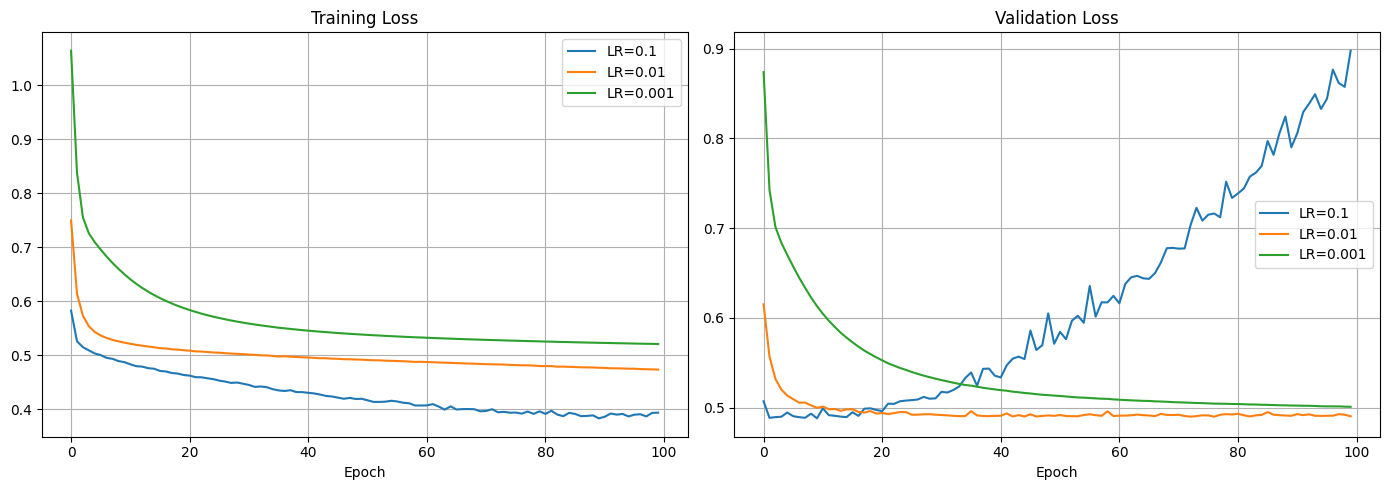

In [ ]:
# Perbandingan traning & validation loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr in learning_rates:
    axes[0].plot(histories[lr]['train_loss'], label=f'LR={lr}')
    axes[1].plot(histories[lr]['val_loss'],   label=f'LR={lr}')

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

LR=0.1 konvergen paling cepat dan mencapai training loss terendah (~0.41), namun validation loss-nya naik secara signifikan setelah epoch ~40 hingga mencapai ~0.64 mengindikasikan terjadinya **overfitting**. LR=0.01 menunjukkan konvergensi yang stabil dengan gap training dan validation loss yang kecil dan konsisten. LR=0.001 konvergen paling lambat dan training loss masih turun di epoch 100, mengindikasikan model **belum konvergen** sepenuhnya dalam 100 epoch.

In [ ]:
# Perbandingan akurasi akhir

for lr in learning_rates:
    print(f"LR={lr:5} | Test Accuracy: {results[lr]['accuracy']:.4f}")

LR=  0.1 | Test Accuracy: 0.7055
LR= 0.01 | Test Accuracy: 0.7515
LR=0.001 | Test Accuracy: 0.7370


LR=0.01 menghasilkan akurasi tertinggi (75.20%). LR=0.1 terlalu besar sehingga overshoot saat update bobot, menghasilkan akurasi terendah. LR=0.001 performanya cukup baik namun belum optimal karena dengan 100 epoch kemungkinan belum sepenuhnya konvergen.


LR = 0.1

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.1092    | 1.3630     | 0.0136     | 0.3468    
        | b     | -0.4159    | 0.2338     | -0.0993    | 0.1449    
-----------------------------------------------------------------
2       | W     | -1.0125    | 0.6906     | -0.0076    | 0.2557    
        | b     | -0.1880    | 0.1509     | -0.0148    | 0.0875    
-----------------------------------------------------------------
3       | W     | -1.2667    | 1.0230     | -0.0478    | 0.6474    
        | b     | -0.3131    | 0.3131     | -0.0000    | 0.3131    
-----------------------------------------------------------------


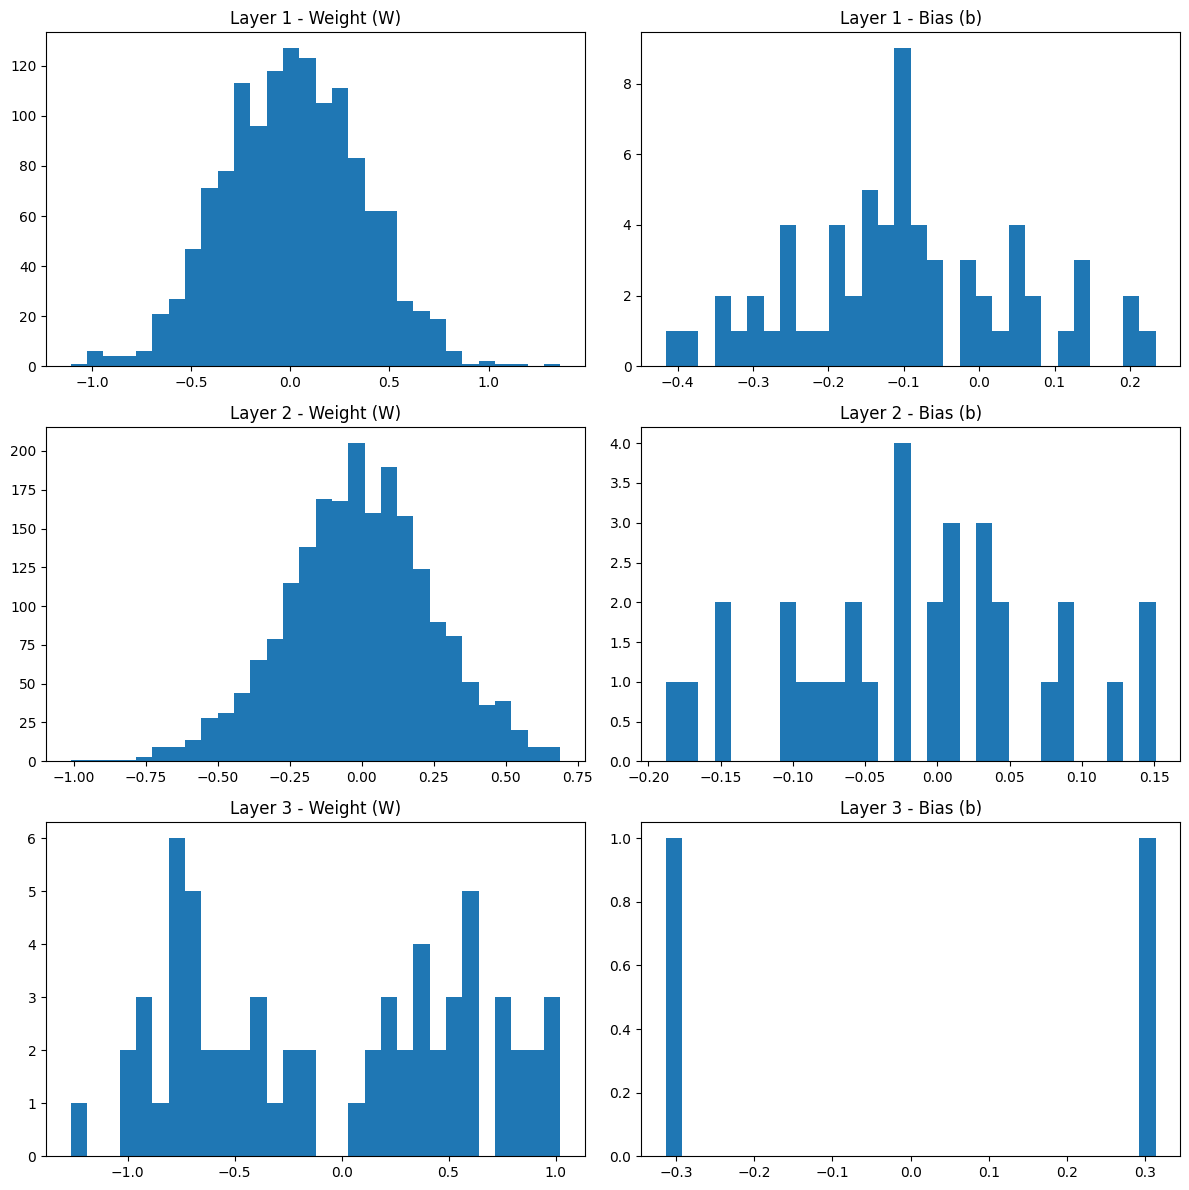


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


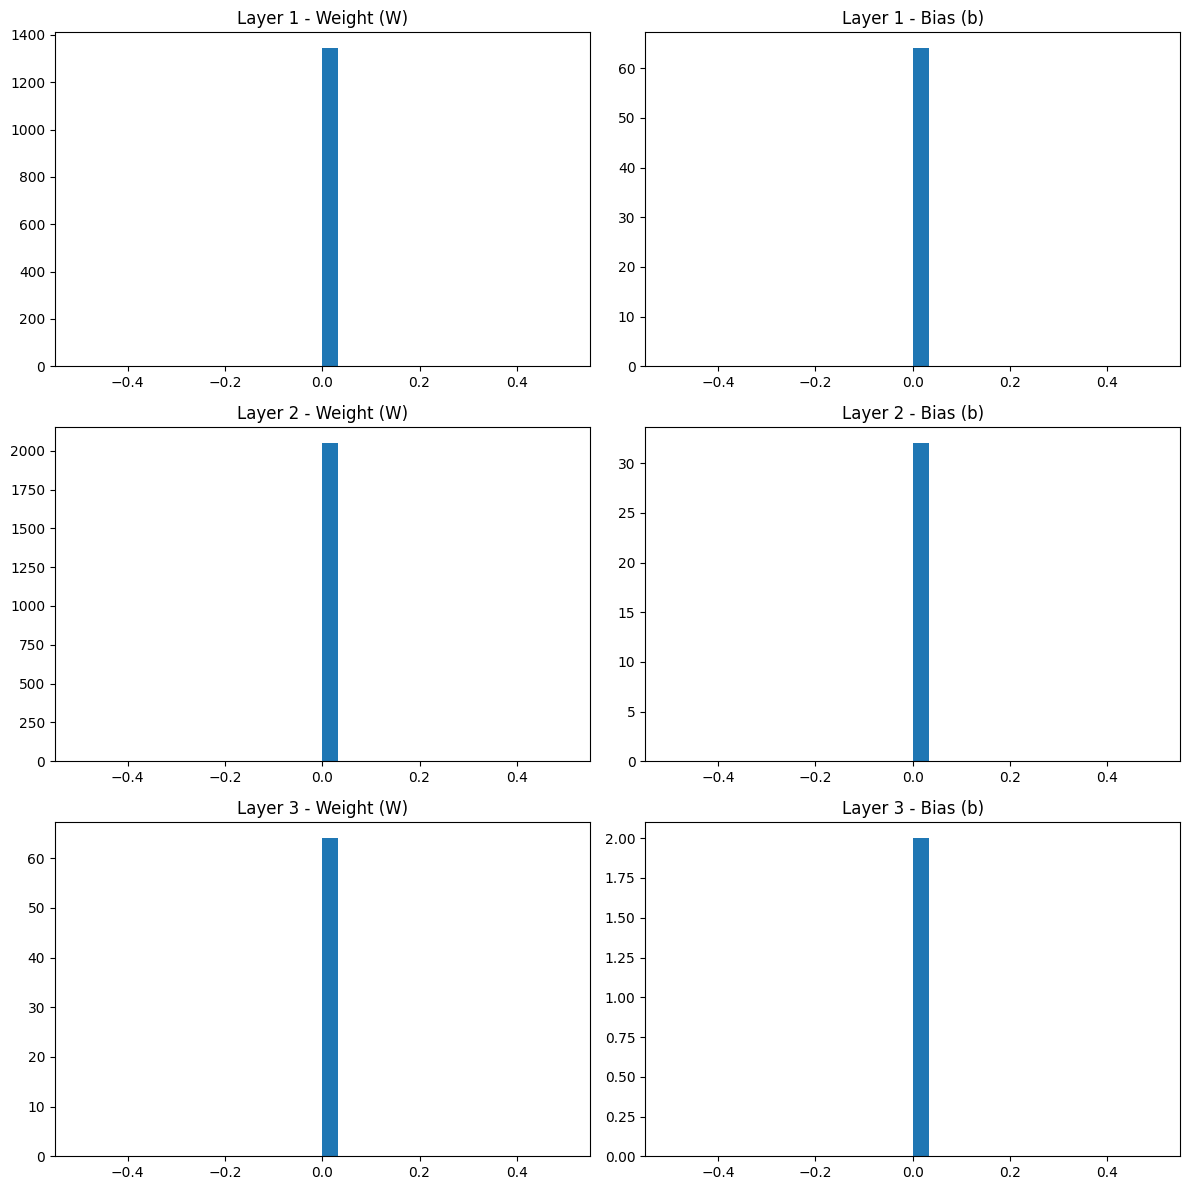


LR = 0.01

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.0437    | 1.2665     | 0.0118     | 0.3032    
        | b     | -0.0512    | 0.1845     | 0.0081     | 0.0354    
-----------------------------------------------------------------
2       | W     | -0.5715    | 0.6632     | 0.0062     | 0.1754    
        | b     | -0.0262    | 0.0307     | 0.0000     | 0.0112    
-----------------------------------------------------------------
3       | W     | -0.4819    | 0.4490     | -0.0478    | 0.2303    
        | b     | -0.0123    | 0.0123     | -0.0000    | 0.0123    
-----------------------------------------------------------------


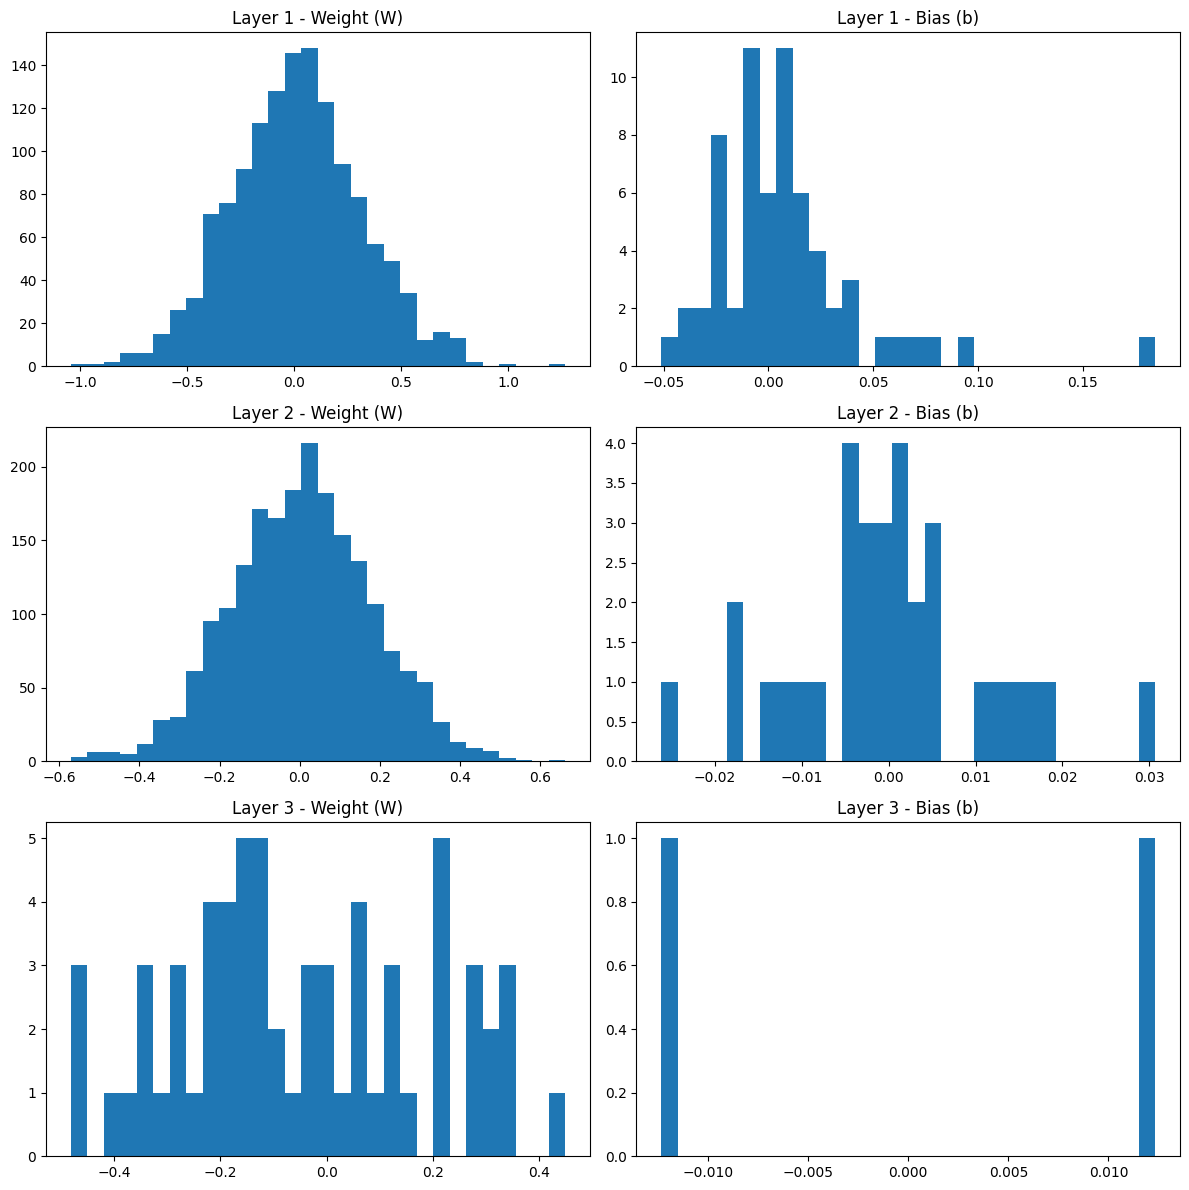


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


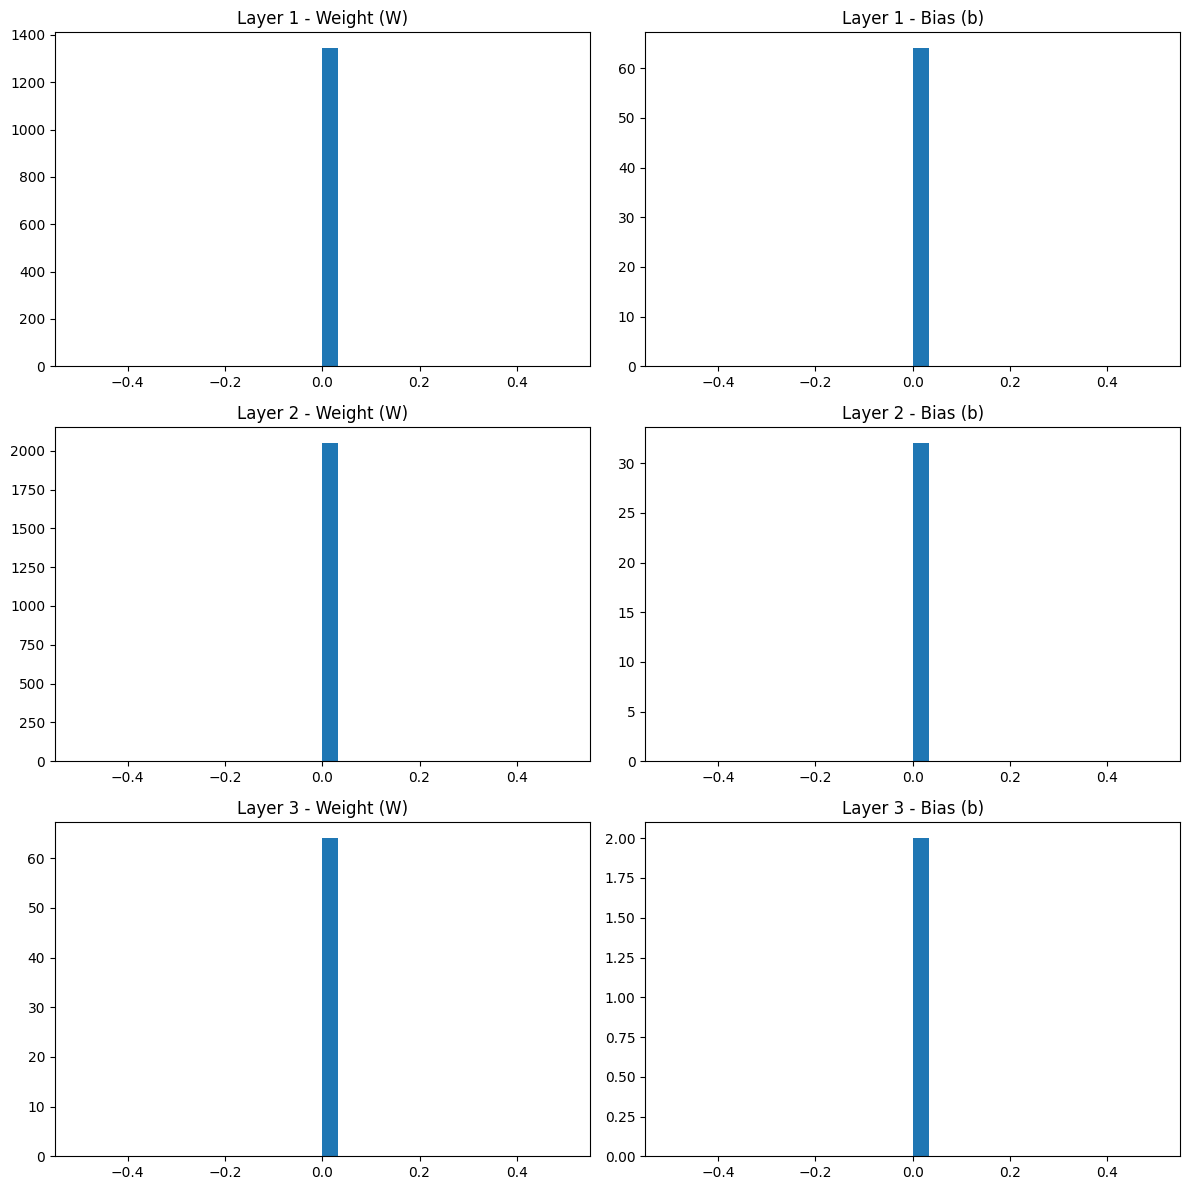


LR = 0.001

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.0263    | 1.1762     | 0.0120     | 0.3027    
        | b     | -0.0196    | 0.0507     | 0.0019     | 0.0118    
-----------------------------------------------------------------
2       | W     | -0.5666    | 0.6722     | 0.0074     | 0.1744    
        | b     | -0.0207    | 0.0454     | 0.0009     | 0.0129    
-----------------------------------------------------------------
3       | W     | -0.4507    | 0.4291     | -0.0478    | 0.2083    
        | b     | -0.0424    | 0.0424     | 0.0000     | 0.0424    
-----------------------------------------------------------------


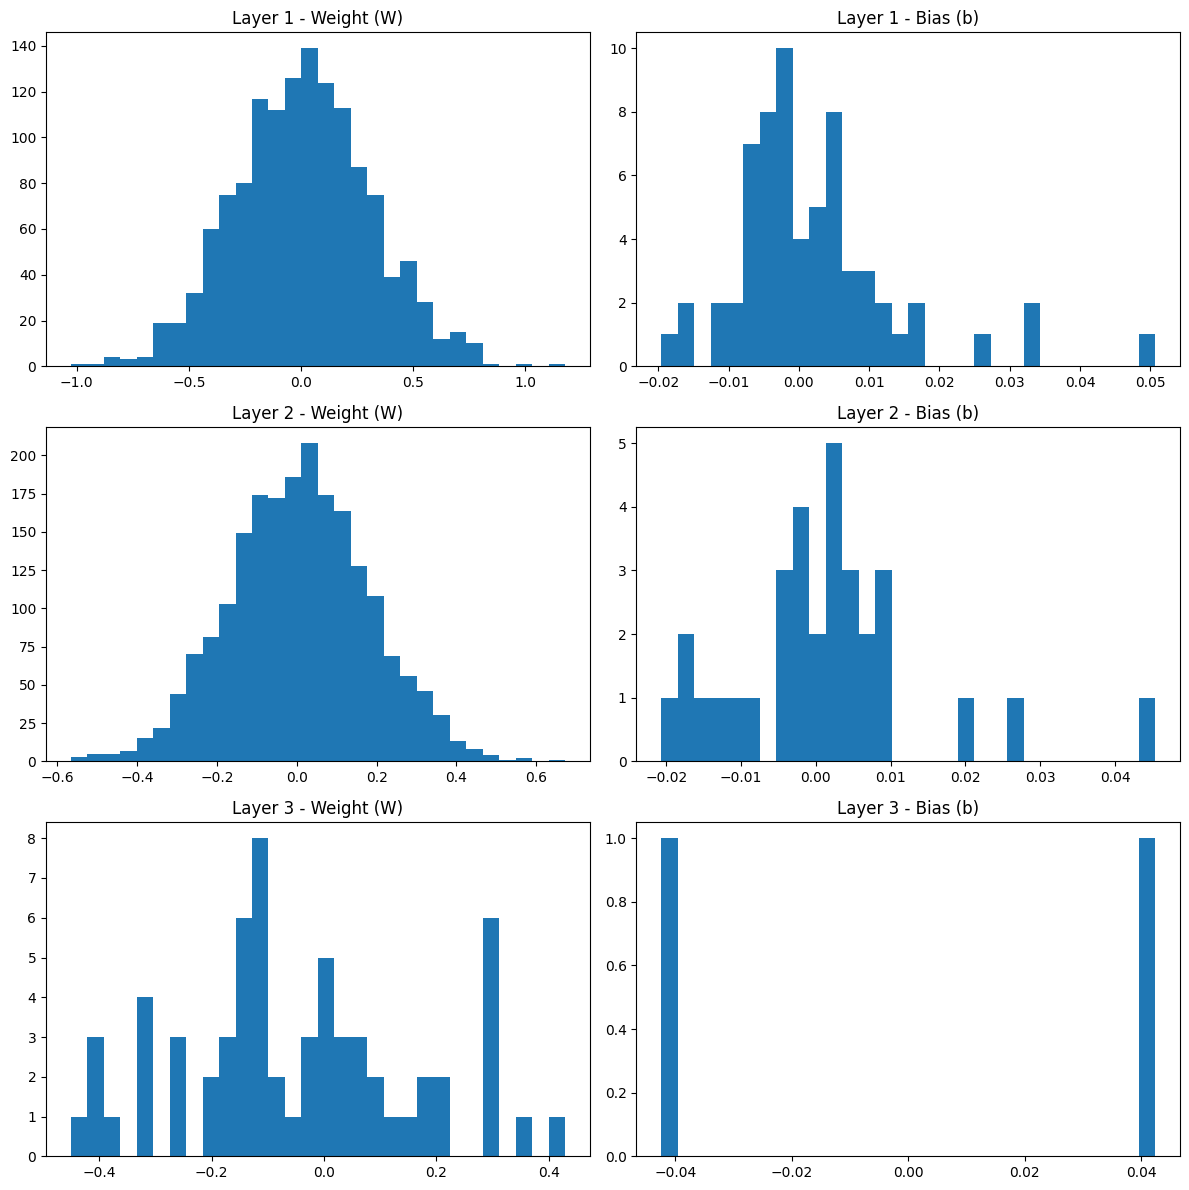


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


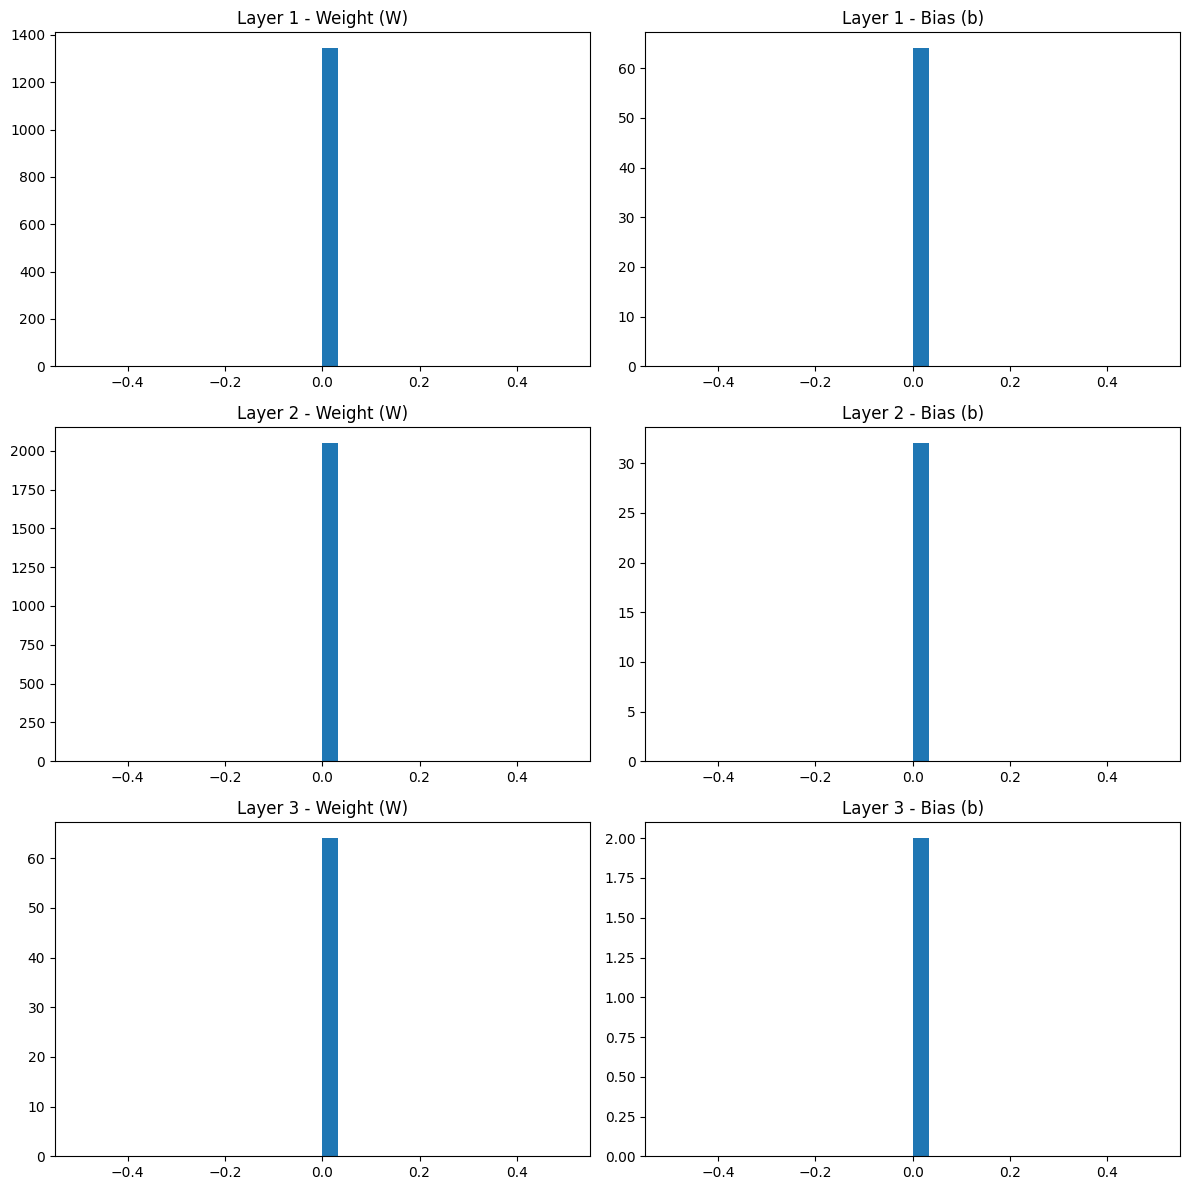

In [ ]:
# Distribusi bobot dan gradien

for lr in learning_rates:
    print(f"\n{'='*50}\nLR = {lr}\n{'='*50}")
    results[lr]['model'].display_weight_distribution([1, 2, 3])
    results[lr]['model'].display_gradient_distribution([1, 2, 3])

LR=0.1 menghasilkan bobot dengan rentang dan std yang lebih besar (bobot tersebar lebih lebar), menunjukkan update yang agresif. LR=0.01 dan LR=0.001 menghasilkan distribusi bobot yang lebih terpusat di sekitar nol. Dari sisi gradien, LR=0.1 menunjukkan gradien yang lebih besar di layer awal, sementara LR=0.001 memiliki gradien yang sangat kecil.

#### Kesimpulan

LR=0.01 adalah pilihan optimal untuk dataset ini, karena seperti yang dapat dilihat pada pengujian di atas, LR ini menghasilkan akurasi tertinggi (75.20%) dengan kurva loss yang stabil dan tidak overfit. LR=0.1 meskipun training loss nya rendah, terbukti overfit dilihat dari validation loss yang naik. LR=0.001 belum konvergen dalam 100 epoch sehingga membutuhkan lebih banyak iterasi untuk mencapai performa optimal.

### 2. Pengaruh Regularisasi

Eksperimen dengan 3 kondisi: tanpa regularisasi, L1, dan L2.

In [ ]:
LAYER_SIZES = [X_train.shape[1], 64, 32, 2]
ACTIVATIONS = ["relu", "relu", "softmax"]
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42

regularizations = {
    "No Reg":   {"l1_lambda": 0.0,    "l2_lambda": 0.0},
    "L1":       {"l1_lambda": 0.0001, "l2_lambda": 0.0},
    "L2":       {"l1_lambda": 0.0,    "l2_lambda": 0.0001},
}

histories_reg = {}
results_reg = {}

for name, reg_params in regularizations.items():
    print(f"\n{'='*50}\nTraining dengan {name}\n{'='*50}")
    model = FFNN(
        layer_sizes=LAYER_SIZES,
        activations=ACTIVATIONS,
        init_method="he",
        learning_rate=0.001,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=1,
        **reg_params
    )
    history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
    histories_reg[name] = history
    results_reg[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test.ravel(), np.argmax(model.predict(X_test), axis=1))
    }


Training dengan No Reg
Epoch   1/100 [>....................] - loss: 1.0640 - acc: 0.4836 - val_loss: 0.8737 - val_acc: 0.5200
Epoch   2/100 [>....................] - loss: 0.8377 - acc: 0.5467 - val_loss: 0.7423 - val_acc: 0.5925
Epoch   3/100 [>....................] - loss: 0.7551 - acc: 0.5960 - val_loss: 0.7013 - val_acc: 0.6462
Epoch   4/100 [>....................] - loss: 0.7257 - acc: 0.6179 - val_loss: 0.6836 - val_acc: 0.6500
Epoch   5/100 [=>...................] - loss: 0.7092 - acc: 0.6285 - val_loss: 0.6701 - val_acc: 0.6675
Epoch   6/100 [=>...................] - loss: 0.6956 - acc: 0.6358 - val_loss: 0.6572 - val_acc: 0.6737
Epoch   7/100 [=>...................] - loss: 0.6826 - acc: 0.6428 - val_loss: 0.6449 - val_acc: 0.6775
Epoch   8/100 [=>...................] - loss: 0.6707 - acc: 0.6461 - val_loss: 0.6336 - val_acc: 0.6837
Epoch   9/100 [=>...................] - loss: 0.6599 - acc: 0.6517 - val_loss: 0.6228 - val_acc: 0.6850
Epoch  10/100 [==>..................] - 

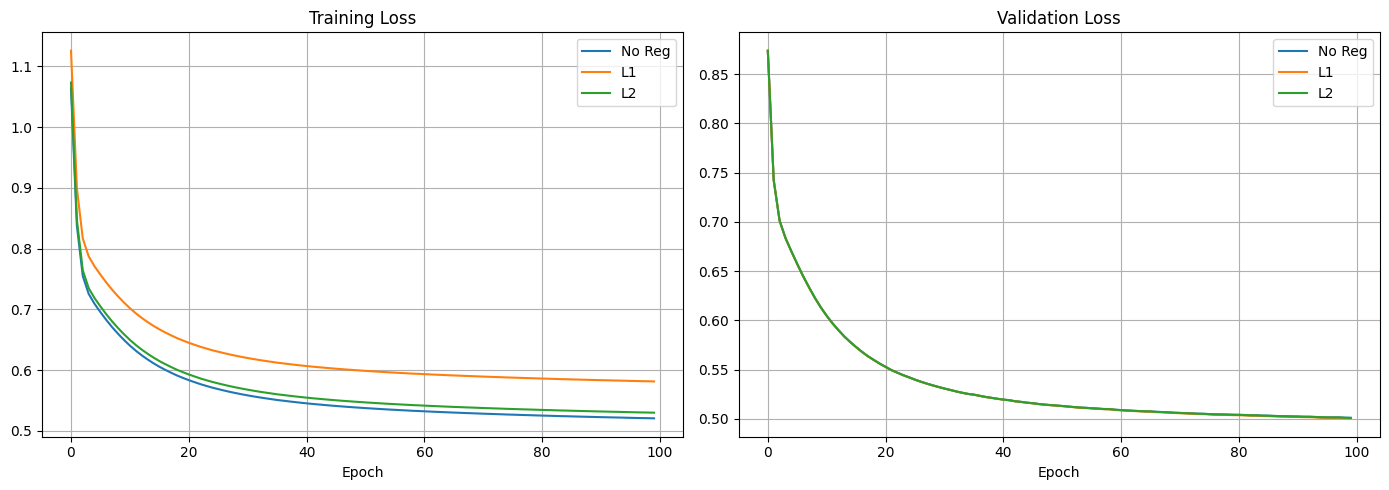

In [ ]:
# Perbandingan training & validation loss

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in regularizations:
    axes[0].plot(histories_reg[name]['train_loss'], label=name)
    axes[1].plot(histories_reg[name]['val_loss'],   label=name)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

No Reg dan L2 menunjukkan kurva training loss yang hampir identik dan berhimpit, keduanya konvergen ke sekitar ~0.52. L1 konvergen lebih lambat dan berhenti di training loss yang lebih tinggi (~0.58), karena penalti L1 yang mendorong sparsity membuat optimisasi lebih sulit. Pada validation loss, ketiga model juga hampir berhimpit dan konvergen ke nilai yang sama (~0.49), menunjukkan bahwa regularisasi dengan lambda=0.0001 tidak memberikan dampak signifikan terhadap generalisasi model pada dataset ini.

In [ ]:
# Perbandingan akurasi akhir

for name in regularizations:
    print(f"{name:<10} | Test Accuracy: {results_reg[name]['accuracy']:.4f}")

No Reg     | Test Accuracy: 0.7370
L1         | Test Accuracy: 0.7370
L2         | Test Accuracy: 0.7370


Ketiga model menghasilkan akurasi yang hampir identik. Hal ini wajar karena nilai lambda yang digunakan (0.0001) sangat kecil sehingga pengaruh regularisasi terhadap bobot minimal. L2 menyamai No Regularisasi, sementara L1 sedikit lebih rendah kemungkinan karena penalti L1 mendorong sparsity yang sedikit mengurangi kapasitas model.


No Reg

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.0263    | 1.1762     | 0.0120     | 0.3027    
        | b     | -0.0196    | 0.0507     | 0.0019     | 0.0118    
-----------------------------------------------------------------
2       | W     | -0.5666    | 0.6722     | 0.0074     | 0.1744    
        | b     | -0.0207    | 0.0454     | 0.0009     | 0.0129    
-----------------------------------------------------------------
3       | W     | -0.4507    | 0.4291     | -0.0478    | 0.2083    
        | b     | -0.0424    | 0.0424     | 0.0000     | 0.0424    
-----------------------------------------------------------------


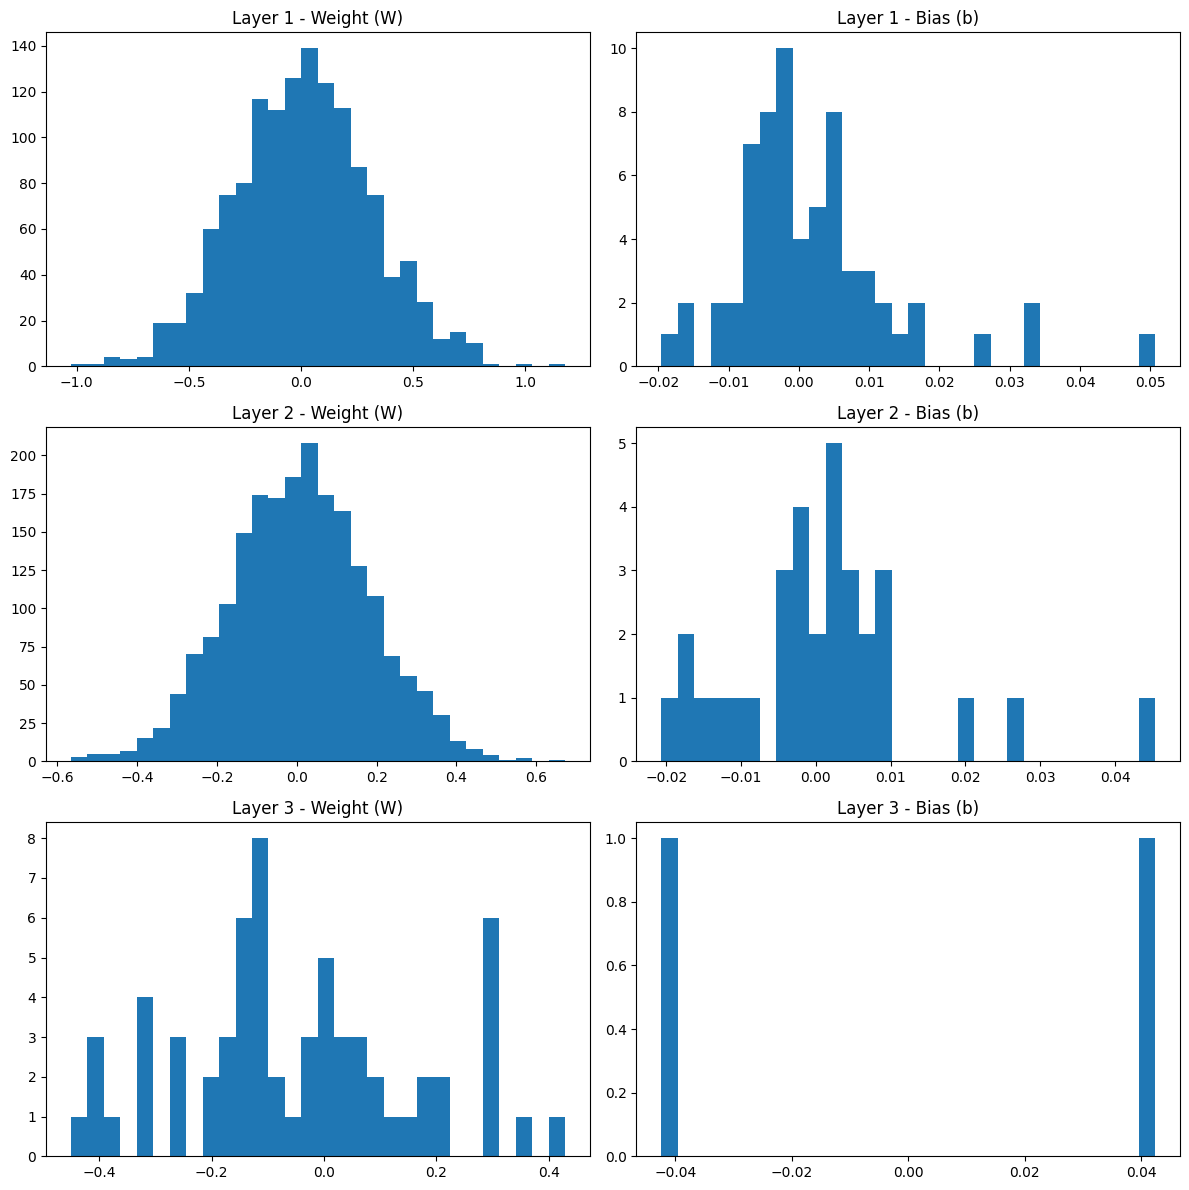


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


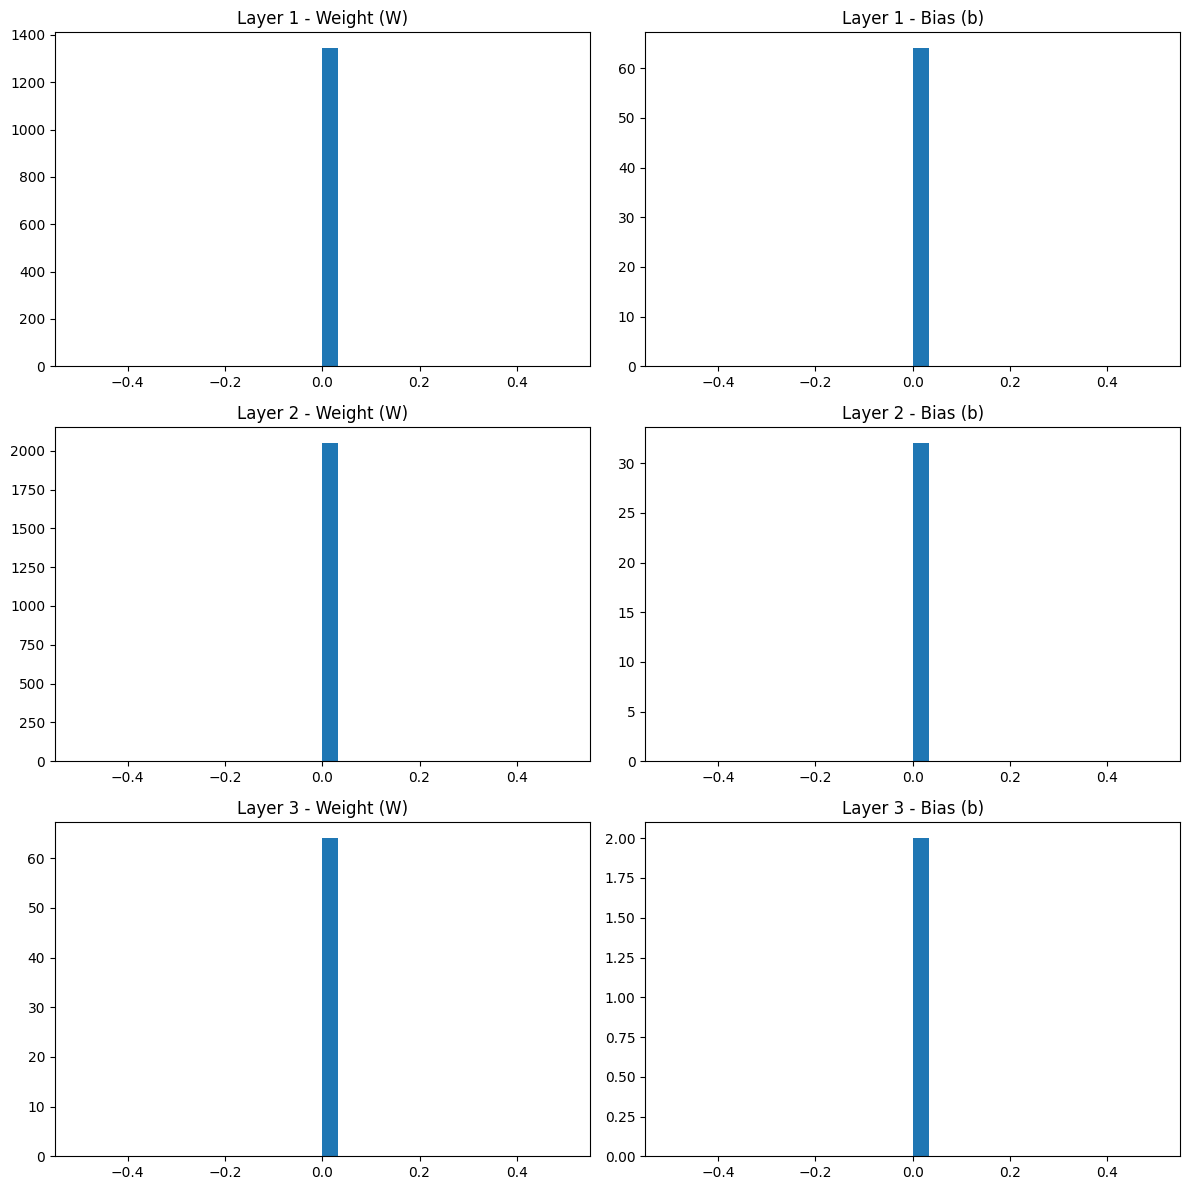


L1

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.0241    | 1.1737     | 0.0119     | 0.3009    
        | b     | -0.0198    | 0.0507     | 0.0020     | 0.0118    
-----------------------------------------------------------------
2       | W     | -0.5643    | 0.6701     | 0.0073     | 0.1727    
        | b     | -0.0206    | 0.0455     | 0.0010     | 0.0129    
-----------------------------------------------------------------
3       | W     | -0.4500    | 0.4283     | -0.0474    | 0.2071    
        | b     | -0.0428    | 0.0428     | 0.0000     | 0.0428    
-----------------------------------------------------------------


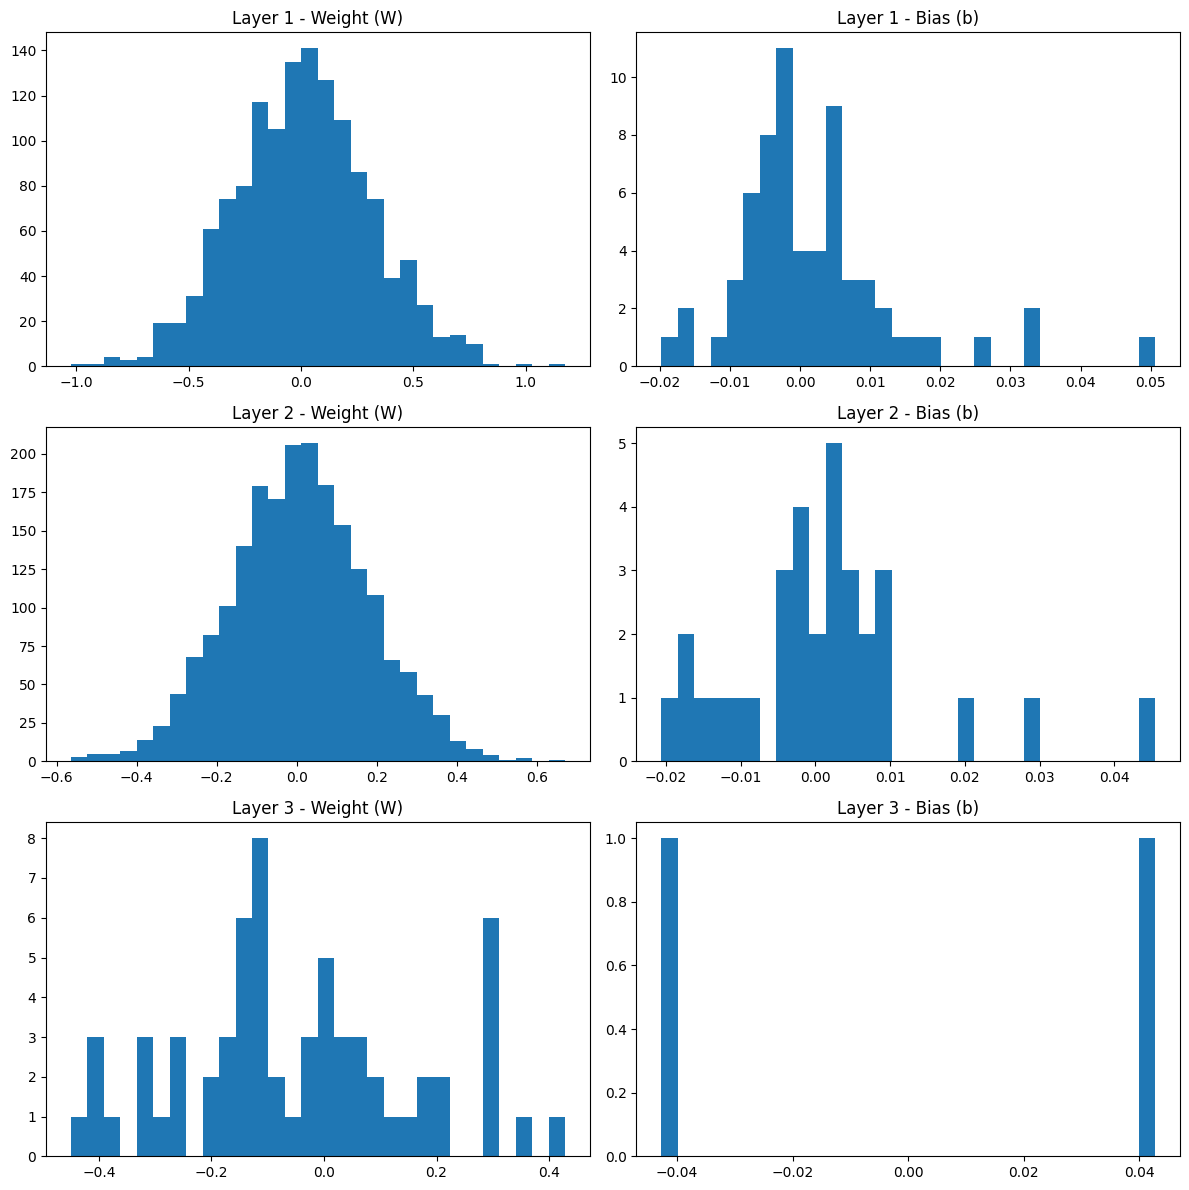


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


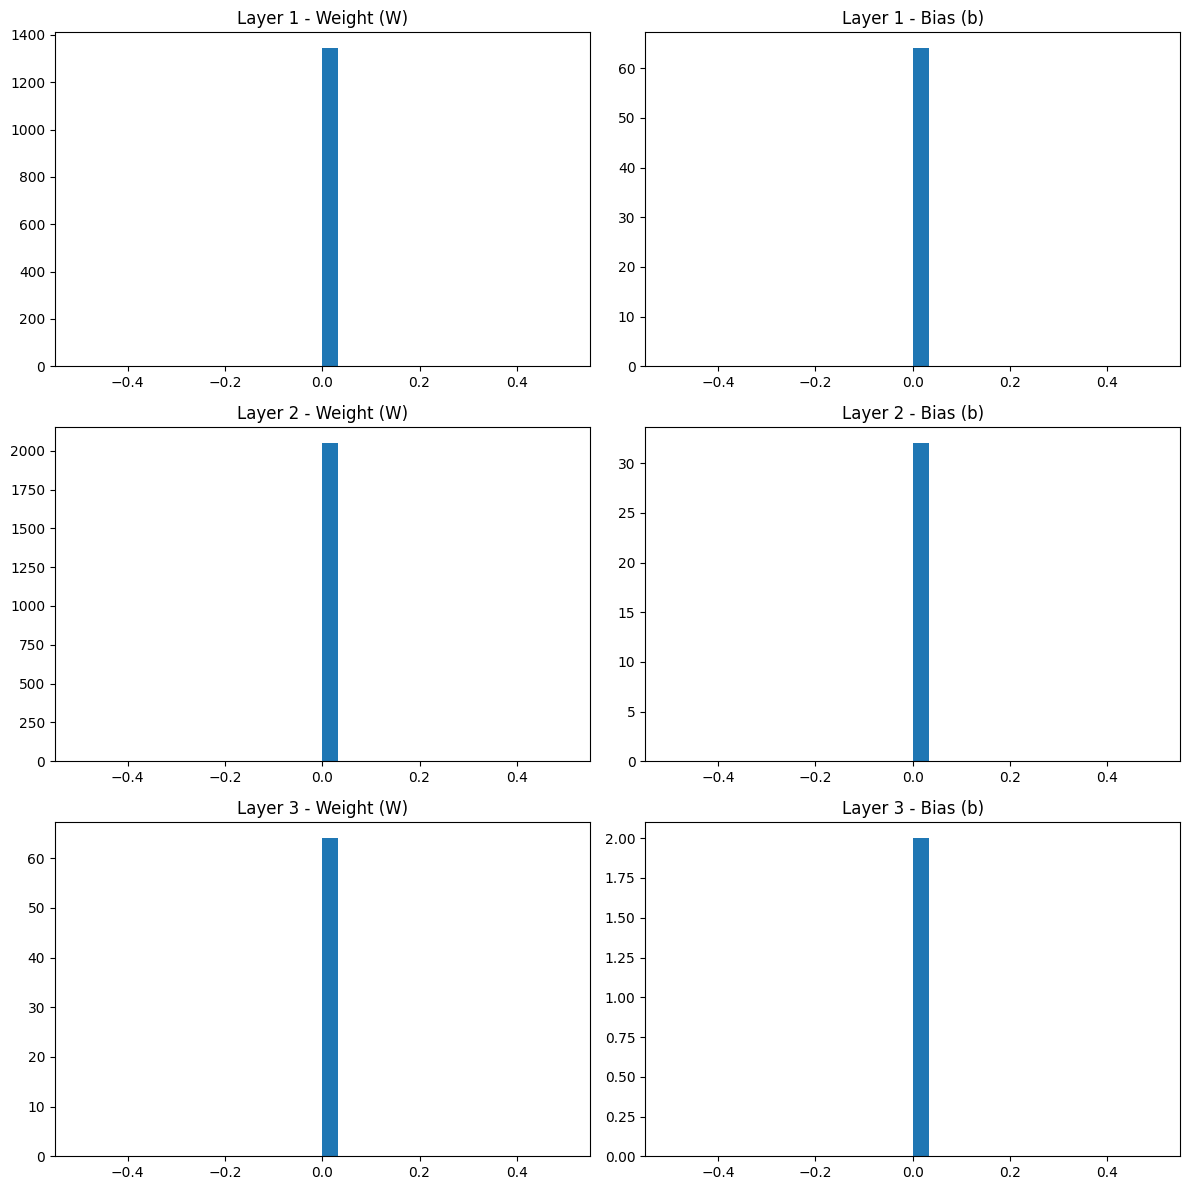


L2

               DISTRIBUSI BOBOT (WEIGHTS) & BIAS                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | W     | -1.0241    | 1.1735     | 0.0120     | 0.3020    
        | b     | -0.0196    | 0.0507     | 0.0020     | 0.0118    
-----------------------------------------------------------------
2       | W     | -0.5653    | 0.6707     | 0.0074     | 0.1741    
        | b     | -0.0207    | 0.0454     | 0.0009     | 0.0129    
-----------------------------------------------------------------
3       | W     | -0.4502    | 0.4286     | -0.0477    | 0.2080    
        | b     | -0.0425    | 0.0425     | -0.0000    | 0.0425    
-----------------------------------------------------------------


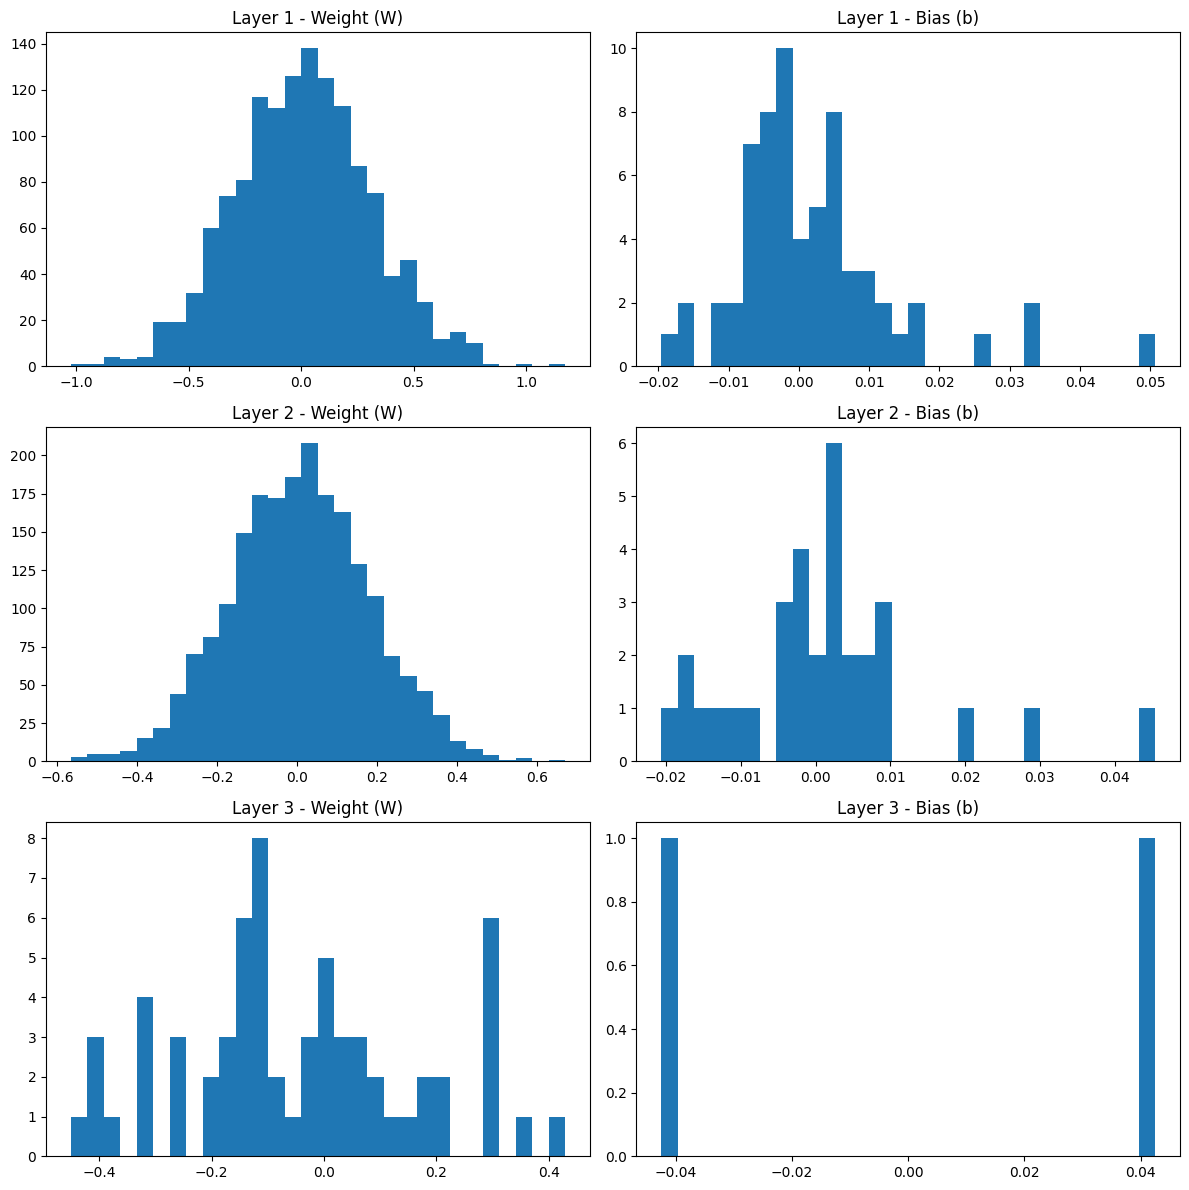


               DISTRIBUSI GRADIEN (ERROR SIGNAL)                 
Layer   | Param | Min        | Max        | Mean       | Std       
-----------------------------------------------------------------
1       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
2       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------
3       | dW    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
        | db    | 0.0000     | 0.0000     | 0.0000     | 0.0000    
-----------------------------------------------------------------


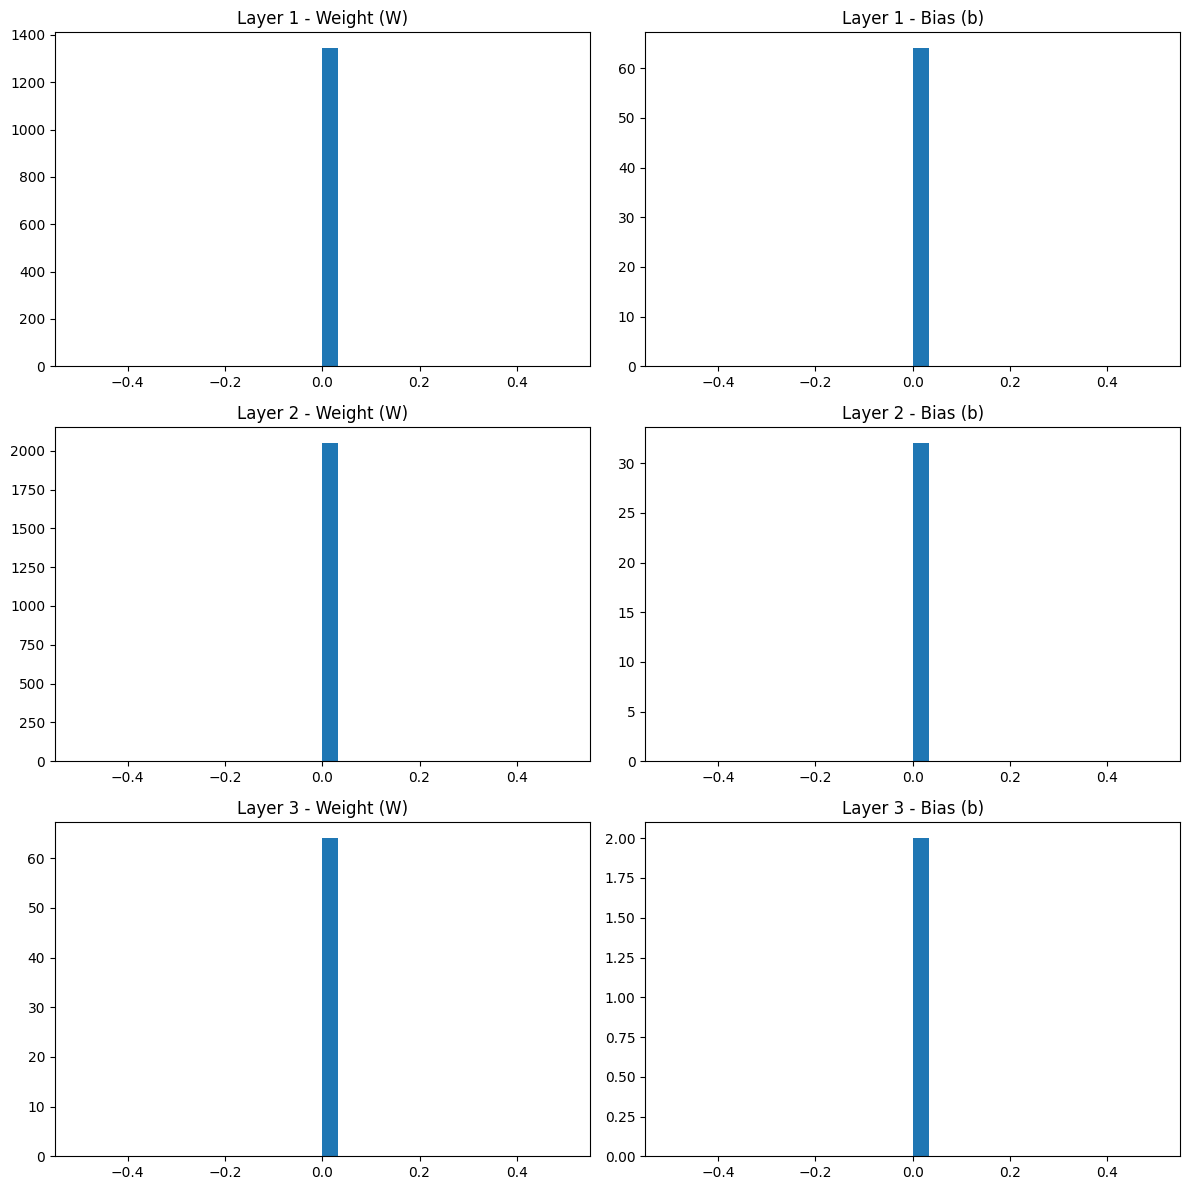

In [ ]:
# dist bobot and bias

for name in regularizations:
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    results_reg[name]['model'].display_weight_distribution([1, 2, 3])
    results_reg[name]['model'].display_gradient_distribution([1, 2, 3])

Model dengan L1 cenderung menghasilkan bobot yang lebih sparse (banyak nilai mendekati nol) karena sifat penalti L1 yang mendorong sparsity. L2 menghasilkan bobot dengan magnitude yang sedikit lebih kecil secara keseluruhan (weight decay) dibanding No Reg, namun distribusinya tetap smooth. Gradien pada L1 dan L2 sedikit lebih besar dibanding No Reg karena ada tambahan gradient dari penalty term.

**Kesimpulan**

Pada dataset ini dengan lambda=0.0001, regularisasi L1 dan L2 tidak memberikan perbedaan signifikan terhadap akurasi akhir maupun kurva loss. Ini mengindikasikan model tidak mengalami overfitting yang berarti pada konfigurasi yang digunakan, sehingga regularisasi tidak terlalu diperlukan.

### 3. Uji Perbandingan dengan Library sklearn MLP

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Buat model sklearn MLP
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=100,
    batch_size=32,
    random_state=42,
    verbose=1
)

# Training
print("Training sklearn MLPClassifier...")
sklearn_model.fit(X_train, y_train.ravel())

# Prediksi
y_pred_sklearn = sklearn_model.predict(X_test)

# Comparison Report
print("\n" + "="*60)
print("PERBANDINGAN MODEL")
print("="*60)

# Custom FFNN accuracy
y_pred_custom_labels = np.argmax(y_pred_probs, axis=1)
accuracy_custom = np.mean(y_pred_custom_labels == y_test.ravel())
print(f"\nCustom FFNN Accuracy: {accuracy_custom:.4f}")

# sklearn accuracy
accuracy_sklearn = accuracy_score(y_test.ravel(), y_pred_sklearn)
print(f"sklearn MLPClassifier Accuracy: {accuracy_sklearn:.4f}")

print("\n" + "="*60)
print("SKLEARN MODEL - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test.ravel(), y_pred_sklearn))

print("\n" + "="*60)
print("CONFUSION MATRIX - SKLEARN")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_sklearn))

Training sklearn MLPClassifier...
Iteration 1, loss = 0.53837952
Iteration 2, loss = 0.50670980
Iteration 3, loss = 0.49918055
Iteration 4, loss = 0.49340184
Iteration 5, loss = 0.49062160
Iteration 6, loss = 0.48693599
Iteration 7, loss = 0.48121978
Iteration 8, loss = 0.47743500
Iteration 9, loss = 0.47599820
Iteration 10, loss = 0.47272008
Iteration 11, loss = 0.46660229
Iteration 12, loss = 0.46506111
Iteration 13, loss = 0.45926103
Iteration 14, loss = 0.45540327
Iteration 15, loss = 0.45415943
Iteration 16, loss = 0.45388782
Iteration 17, loss = 0.44738950
Iteration 18, loss = 0.44186089
Iteration 19, loss = 0.44017896
Iteration 20, loss = 0.43608018
Iteration 21, loss = 0.43216597
Iteration 22, loss = 0.43086166
Iteration 23, loss = 0.42301607
Iteration 24, loss = 0.42375110
Iteration 25, loss = 0.42006351
Iteration 26, loss = 0.41535082
Iteration 27, loss = 0.41312305
Iteration 28, loss = 0.41304536
Iteration 29, loss = 0.40893100
Iteration 30, loss = 0.40699142
Iteration 31, l

c:\Users\rafis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from ffnn.optimizer import AdamOptimizer
print(AdamOptimizer)  # pastikan ini class, bukan None
adam = AdamOptimizer()
print(adam.update)    # pastikan ini bound method

<class 'ffnn.optimizer.AdamOptimizer'>
<bound method AdamOptimizer.update of <ffnn.optimizer.AdamOptimizer object at 0x0000015D883E7E10>>


Epoch   1/100 [>....................] - loss: 0.6060 - acc: 0.6999 - val_loss: 0.5025 - val_acc: 0.7612
Epoch   2/100 [>....................] - loss: 0.5238 - acc: 0.7449 - val_loss: 0.4946 - val_acc: 0.7588
Epoch   3/100 [>....................] - loss: 0.5086 - acc: 0.7547 - val_loss: 0.4909 - val_acc: 0.7550
Epoch   4/100 [>....................] - loss: 0.4980 - acc: 0.7575 - val_loss: 0.4885 - val_acc: 0.7650
Epoch   5/100 [=>...................] - loss: 0.4902 - acc: 0.7654 - val_loss: 0.4919 - val_acc: 0.7700
Epoch   6/100 [=>...................] - loss: 0.4840 - acc: 0.7700 - val_loss: 0.4845 - val_acc: 0.7738
Epoch   7/100 [=>...................] - loss: 0.4796 - acc: 0.7694 - val_loss: 0.4814 - val_acc: 0.7725
Epoch   8/100 [=>...................] - loss: 0.4754 - acc: 0.7762 - val_loss: 0.4869 - val_acc: 0.7625
Epoch   9/100 [=>...................] - loss: 0.4677 - acc: 0.7785 - val_loss: 0.4911 - val_acc: 0.7600
Epoch  10/100 [==>..................] - loss: 0.4644 - acc: 0.78

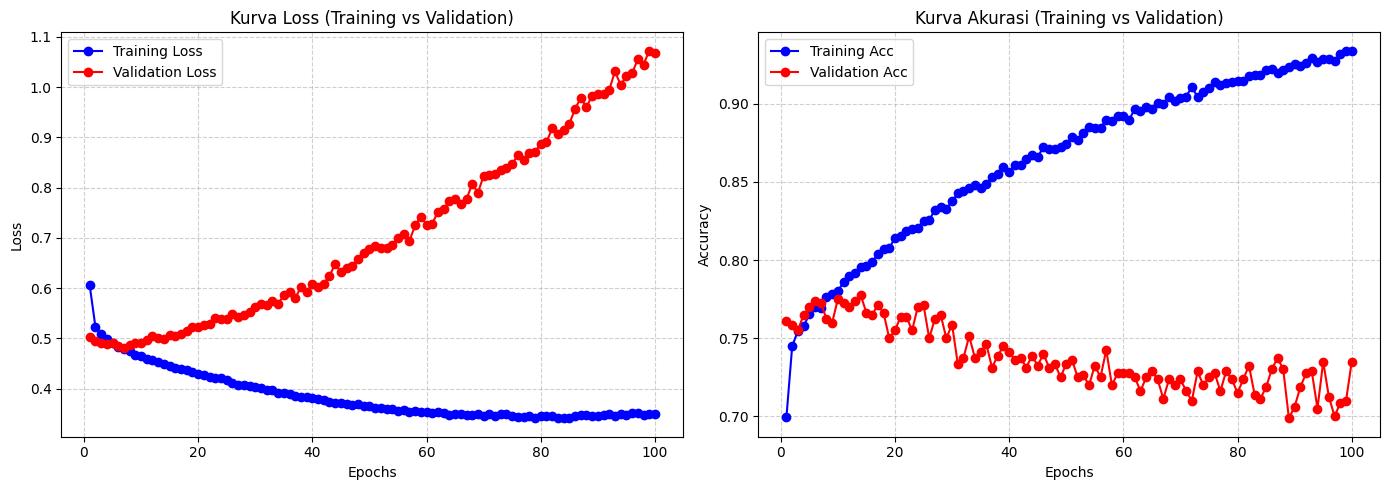


Custom FFNN Accuracy: 0.6885


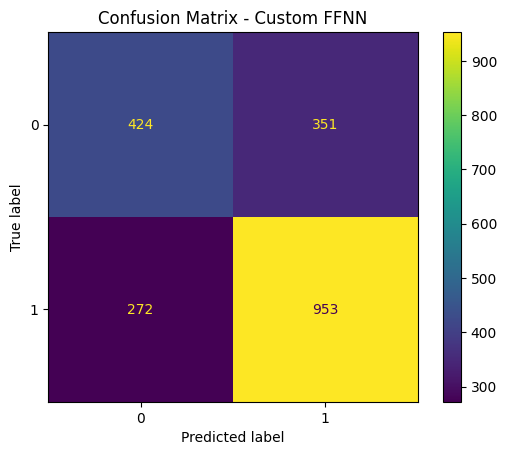

In [ ]:
from ffnn.ffnn import FFNN
from ffnn import utils
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Shared hyperparams
HIDDEN_LAYERS = (64, 32)
LR = 0.001
EPOCHS = 100
BATCH_SIZE = 32
SEED = 42

y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_val_onehot   = utils.create_one_hot(y_val.ravel(), num_classes=2)
y_test_onehot  = utils.create_one_hot(y_test.ravel(), num_classes=2)

model = FFNN(
    layer_sizes=[X_train.shape[1], *HIDDEN_LAYERS, 2],
    activations=["relu", "relu", "softmax"],
    init_method="he",
    learning_rate=LR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
    verbose=1,
    optimizer="adam"
)

history = model.fit(X_train, y_train_onehot, X_val=X_val, y_val=y_val_onehot)
utils.plot_history(history)

y_pred = np.argmax(model.predict(X_test), axis=1)
print(f"\nCustom FFNN Accuracy: {accuracy_score(y_test.ravel(), y_pred):.4f}")

cm = confusion_matrix(y_test.ravel(), y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Custom FFNN")
plt.show()

c:\Users\rafis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



Sklearn MLP Accuracy: 0.6920


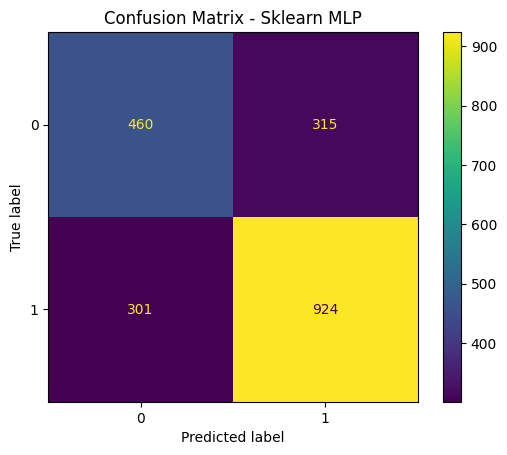

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

sklearn_model = MLPClassifier(
    hidden_layer_sizes=HIDDEN_LAYERS,   # same (64, 32)
    activation="relu",                  # same
    solver="adam",                       # same as custom (vanilla GD)
    learning_rate_init=LR,              # same 0.001
    max_iter=EPOCHS,                    # same 100
    batch_size=BATCH_SIZE,              # same 32
    random_state=SEED,                  # same 42
    verbose=0,
)

sklearn_model.fit(X_train, y_train.ravel())

y_pred_sk = sklearn_model.predict(X_test)
print(f"\nSklearn MLP Accuracy: {accuracy_score(y_test.ravel(), y_pred_sk):.4f}")

cm_sk = confusion_matrix(y_test.ravel(), y_pred_sk)
ConfusionMatrixDisplay(cm_sk).plot()
plt.title("Confusion Matrix - Sklearn MLP")
plt.show()